Download HVSA full episodes

In [ ]:
import pandas as pd
import requests
from urllib.parse import unquote
import os

# Load the CSV file
csv_path = "C:/Users/Nikhi/OneDrive/Desktop/stuttering/SEP-28k_joined_labels_episodes.csv"
df = pd.read_csv(csv_path)

# Filter for HVSA episodes (adjust column names as needed)
hvsa_df = df[df['Podcast'] == 'Hudson_Valley_Stuttering_Association']  # Replace 'podcast' with the actual column name

# Directory to save recordings
output_dir = "C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes/HVSA"
os.makedirs(output_dir, exist_ok=True)

for idx, row in hvsa_df.iterrows():
    url = row['URL']  # Replace with the actual column name for the URL
    unquoted_url = unquote(url)
    filename = os.path.join(output_dir, f"episode_{row['EpID']}.mp3")  # Adjust filename logic as needed

    try:
        response = requests.get(unquoted_url, stream=True)
        response.raise_for_status()
        with open(filename, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded: {filename}")
    except Exception as e:
        print(f"Failed to download {unquoted_url}: {e}")

Downloaded: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes/HVSA\episode_0.mp3
Downloaded: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes/HVSA\episode_0.mp3
Downloaded: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes/HVSA\episode_0.mp3
Downloaded: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes/HVSA\episode_0.mp3
Downloaded: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes/HVSA\episode_0.mp3
Downloaded: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes/HVSA\episode_0.mp3
Downloaded: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes/HVSA\episode_0.mp3
Downloaded: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes/HVSA\episode_0.mp3
Downloaded: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes/HVSA\episode_0.mp3
Downloaded: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes/HVSA\episode_0.mp3
Downloaded: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes/HVSA\episode_0.mp3
Downloaded: C:/Users/Nikhi/OneDr

In [28]:
import os
from pathlib import Path

root = Path(r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\data_sep28k\clips_3s")

for show in root.iterdir():
    if show.is_dir():
        print(f"\nSHOW: {show.name}")
        
        for episode in show.iterdir():
            if episode.is_dir():
                wav_count = len(list(episode.glob("*.wav")))
                print(f"  Episode {episode.name}: {wav_count} wav files")



SHOW: HeStutters
  Episode 0: 40 wav files
  Episode 1: 273 wav files
  Episode 10: 40 wav files
  Episode 11: 208 wav files
  Episode 12: 218 wav files
  Episode 13: 40 wav files
  Episode 14: 40 wav files
  Episode 15: 196 wav files
  Episode 16: 79 wav files
  Episode 17: 40 wav files
  Episode 18: 217 wav files
  Episode 19: 183 wav files
  Episode 2: 216 wav files
  Episode 20: 261 wav files
  Episode 21: 221 wav files
  Episode 22: 207 wav files
  Episode 23: 215 wav files
  Episode 3: 40 wav files
  Episode 4: 40 wav files
  Episode 5: 199 wav files
  Episode 6: 294 wav files
  Episode 7: 40 wav files
  Episode 8: 202 wav files
  Episode 9: 40 wav files

SHOW: HVSA
  Episode 0: 0 wav files
  Episode 1: 0 wav files
  Episode 2: 0 wav files
  Episode 3: 0 wav files

SHOW: MyStutteringLife
  Episode 0: 40 wav files
  Episode 1: 0 wav files
  Episode 10: 0 wav files
  Episode 11: 0 wav files
  Episode 12: 40 wav files
  Episode 13: 0 wav files
  Episode 14: 0 wav files
  Episode 15

In [29]:
import pandas as pd

csv_path = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\SEP-28k_joined_labels_episodes.csv"

# Load CSV
df = pd.read_csv(csv_path)

# Group by Show and Episode (EpId)
counts = df.groupby(["Show", "EpId"]).size().reset_index(name="NumClips")

# Print results
print(counts)

# Optional: Save to CSV
counts.to_csv("clip_counts_by_show_episode.csv", index=False)
print("\nSaved as clip_counts_by_show_episode.csv")


                Show  EpId  NumClips
0               HVSA     0       137
1               HVSA     1       188
2               HVSA     2       200
3               HVSA     3       211
4         HeStutters     0        40
..               ...   ...       ...
380  WomenWhoStutter   105        40
381  WomenWhoStutter   106        40
382  WomenWhoStutter   107        40
383  WomenWhoStutter   108        40
384  WomenWhoStutter   109        40

[385 rows x 3 columns]

Saved as clip_counts_by_show_episode.csv


In [34]:
import os
from pathlib import Path
import pandas as pd

# Paths
csv_path = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\SEP-28k_joined_labels_episodes.csv"
clips_root = Path(r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\data_sep28k\clips_3s")

# Load CSV
df = pd.read_csv(csv_path)

results = []

# Group by Show and EpId
for (show, ep), group in df.groupby(["Show", "EpId"]):

    present_count = 0
    missing_count = 0

    for _, row in group.iterrows():
        clip = str(row["ClipId"])
        expected_name = f"{show}_{ep}_{clip}.wav"
        wav_path = clips_root / str(show) / str(ep) / expected_name

        if wav_path.exists():
            present_count += 1
        else:
            missing_count += 1

    results.append({
        "Show": show,
        "EpId": ep,
        "Present": present_count,
        "Missing": missing_count,
        "Total": present_count + missing_count
    })

# Convert to DataFrame
summary = pd.DataFrame(results)

print(summary)

# Optional: save
summary.to_csv("C:/Users/Nikhi/OneDrive/Desktop/stuttering/clip_presence_summary.csv", index=False)
print("\nSaved summary to clip_presence_summary.csv")


                Show  EpId  Present  Missing  Total
0               HVSA     0        0      137    137
1               HVSA     1        0      188    188
2               HVSA     2        0      200    200
3               HVSA     3        0      211    211
4         HeStutters     0       40        0     40
..               ...   ...      ...      ...    ...
380  WomenWhoStutter   105        0       40     40
381  WomenWhoStutter   106        0       40     40
382  WomenWhoStutter   107        0       40     40
383  WomenWhoStutter   108        0       40     40
384  WomenWhoStutter   109        0       40     40

[385 rows x 5 columns]

Saved summary to clip_presence_summary.csv


Extract 3 sec clips

In [4]:
!pip install pydub


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#download HVSA missing episodes

In [8]:
import os
import urllib.request
from urllib.parse import unquote
import subprocess

# ----------------------------------------------
# SETTINGS
# ----------------------------------------------
save_dir = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\full_episodes\HVSA"
os.makedirs(save_dir, exist_ok=True)

# Episode URLs
urls = {
    "episode_2": "https://anchor.fm/s/184c5dac/podcast/play/11637529/https%3A%2F%2Fd3ctxlq1ktw2nl.cloudfront.net%2Fproduction%2F2020-3-17%2F65403420-44100-1-480bdf97d2168.m4a",
    "episode_3": "https://anchor.fm/s/184c5dac/podcast/play/11637529/https%3A%2F%2Fd3ctxlq1ktw2nl.cloudfront.net%2Fproduction%2F2020-3-17%2F65403420-44100-1-480bdf97d2168.m4a"
}

# ----------------------------------------------
# FUNCTION TO DECODE AND DOWNLOAD EPISODE
# ----------------------------------------------
def download_and_convert(name, encoded_url):

    # Unquote to extract the true m4a URL
    decoded_part = unquote(encoded_url.split("/")[-1])
    if decoded_part.startswith("http"):
        real_url = decoded_part
    else:
        real_url = encoded_url

    print(f"Decoded URL for {name}:")
    print(real_url)

    # Download m4a file
    m4a_path = os.path.join(save_dir, f"{name}.m4a")
    print(f"Downloading {name}...")

    urllib.request.urlretrieve(real_url, m4a_path)
    print(f"Downloaded: {m4a_path}")

    # Convert to MP3
    mp3_path = os.path.join(save_dir, f"{name}.mp3")
    print(f" Converting {name} to MP3...")

    FFMPEG = r"C:\ffmpeg\bin\ffmpeg.exe"   # <-- UPDATE THIS PATH

    cmd = [
        FFMPEG,
        "-i", m4a_path,
        "-vn",
        "-ar", "44100",
        "-ac", "2",
        "-b:a", "192k",
        "-y",
        mp3_path
    ]
    subprocess.run(cmd, check=True)


    print(f" Saved MP3: {mp3_path}\n")
    return mp3_path

# ----------------------------------------------
# RUN FOR EPISODE 2 & 3
# ----------------------------------------------
for name, url in urls.items():
    download_and_convert(name, url)


Decoded URL for episode_2:
https://d3ctxlq1ktw2nl.cloudfront.net/production/2020-3-17/65403420-44100-1-480bdf97d2168.m4a
Downloaded: C:\Users\Nikhi\OneDrive\Desktop\stuttering\full_episodes\HVSA\episode_2.m4a
 Converting episode_2 to MP3...
 Saved MP3: C:\Users\Nikhi\OneDrive\Desktop\stuttering\full_episodes\HVSA\episode_2.mp3

Decoded URL for episode_3:
https://d3ctxlq1ktw2nl.cloudfront.net/production/2020-3-17/65403420-44100-1-480bdf97d2168.m4a
Downloaded: C:\Users\Nikhi\OneDrive\Desktop\stuttering\full_episodes\HVSA\episode_3.m4a
 Converting episode_3 to MP3...
 Saved MP3: C:\Users\Nikhi\OneDrive\Desktop\stuttering\full_episodes\HVSA\episode_3.mp3



# HVSA 3sec clip extraction

In [10]:
import os
import pandas as pd
from tqdm import tqdm
import subprocess

# --- Paths
JOINED_CSV = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/SEP-28k_joined_labels_episodes.csv"
BASE_OUT_DIR = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s/HVSA"
EPISODE_DIR = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes/HVSA"

os.makedirs(BASE_OUT_DIR, exist_ok=True)

# --- Load metadata
meta = pd.read_csv(JOINED_CSV)

# --- Keep only HVSA rows
meta = meta[meta["Show"].str.strip() == "HVSA"].reset_index(drop=True)
print(f"Processing {len(meta)} HVSA clips")

def run_ffmpeg_cut(input_audio, start_s, duration_s, output_path):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    cmd = [
        r"C:\ffmpeg\bin\ffmpeg.exe",   # <-- your ffmpeg path
        "-hide_banner", "-loglevel", "error",
        "-ss", f"{start_s:.2f}", "-t", f"{duration_s:.2f}",
        "-i", input_audio, "-ar", "16000", "-ac", "1", "-y", output_path
    ]
    subprocess.run(cmd, check=True)

# --- Cut HVSA clips
for _, row in tqdm(meta.iterrows(), total=len(meta)):
    epid = str(row["EpId"]).strip()
    clipid = str(row["ClipId"]).strip()

    start_s = float(row["Start_sec"])
    stop_s  = float(row["Stop_sec"])
    dur_s   = stop_s - start_s

    # Path to full episode audio
    input_audio = os.path.join(EPISODE_DIR, f"episode_{epid}.mp3")
    if not os.path.exists(input_audio):
        print(f"Missing episode file: {input_audio}")
        continue

    # --- OUTPUT PATH PER EPISODE (this is the key fix)
    episode_output_dir = os.path.join(BASE_OUT_DIR, epid)  
    clip_path = os.path.join(episode_output_dir, f"HVSA_{epid}_{clipid}.wav")

    # Skip existing clips
    if os.path.exists(clip_path):
        continue

    try:
        run_ffmpeg_cut(input_audio, start_s, dur_s, clip_path)
    except Exception as e:
        print(f"Failed to cut {clip_path}: {e}")

print(f"\nDone! Per-episode clips saved under: {BASE_OUT_DIR}")


Processing 736 HVSA clips


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 736/736 [00:00<00:00, 4189.92it/s]


Done! Per-episode clips saved under: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s/HVSA


In [12]:
#re-download all full episodes - they got erased

In [14]:
import os
import pandas as pd
from urllib.parse import unquote
import urllib.request
import subprocess

# -------------------------------
# CONFIG
# -------------------------------
INPUT_FILE = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\SEP-28k_joined_labels_episodes.csv"

SAVE_ROOT = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes"

FFMPEG = r"C:\ffmpeg\bin\ffmpeg.exe"   # <-- UPDATE THIS PATH


# -------------------------------
# HELPER: Resolve true audio URL
# -------------------------------
def resolve_audio_url(raw_url):
    """
    Fix encoded Anchor.fm URLs:
    https%3A%2F%2Fcloudfront.net%2F...m4a → https://cloudfront.net/...m4a
    """
    raw_url = raw_url.strip()

    # If URL contains percent-encoded real URL
    if "https%3A" in raw_url or "http%3A" in raw_url:
        decoded = unquote(raw_url.split("/")[-1])
        if decoded.startswith("http"):
            return decoded

    return raw_url


# -------------------------------
# HELPER: Download and convert
# -------------------------------
def download_episode(show, epid, url):
    show = show.strip()
    epid = str(epid).strip()

    # decode actual URL
    real_url = resolve_audio_url(url)

    # determine file extension
    ext = real_url.split("?")[0].split(".")[-1]
    if ext not in ["mp3", "m4a", "aac", "wav"]:
        ext = "mp3"

    # output folders
    show_folder = os.path.join(SAVE_ROOT, show)
    os.makedirs(show_folder, exist_ok=True)

    # paths
    raw_path = os.path.join(show_folder, f"{show}_{epid}.{ext}")
    mp3_path = os.path.join(show_folder, f"{show}_{epid}.mp3")

    # skip if mp3 already exists
    if os.path.exists(mp3_path):
        print(f"✔ Already have {mp3_path}")
        return

    # ---------------------
    # STEP 1: DOWNLOAD FILE
    # ---------------------
    print(f"Downloading {show} Ep {epid}...")
    try:
        urllib.request.urlretrieve(real_url, raw_path)
    except Exception as e:
        print(f"Download failed for {real_url}: {e}")
        return

    # If already mp3 → done
    if raw_path.endswith(".mp3"):
        print(f"✔ Saved MP3: {mp3_path}")
        return

    # ----------------------------------
    # STEP 2: Convert to MP3 using ffmpeg
    # ----------------------------------
    print(f"Converting {raw_path} → {mp3_path}...")
    try:
        cmd = [
            FFMPEG,
            "-i", raw_path,
            "-vn",
            "-ar", "44100",
            "-ac", "2",
            "-b:a", "192k",
            "-y",
            mp3_path
        ]
        subprocess.run(cmd, check=True)
        print(f"Saved MP3: {mp3_path}")

    except Exception as e:
        print(f" Conversion failed: {e}")


# -------------------------------
# LOAD DATA
# -------------------------------
df = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df)} rows.")

# Keep only unique episodes by Show + EpId
episodes = df.groupby(["Show", "EpId"], as_index=False).first()

print(f"Found {len(episodes)} unique episodes to download.\n")


# -------------------------------
# DOWNLOAD ALL EPISODES
# -------------------------------
for _, row in episodes.iterrows():
    show = row["Show"]
    epid = row["EpId"]
    url = row["URL"]

    if pd.isna(url) or not isinstance(url, str):
        continue

    download_episode(show, epid, url)

Loaded 28177 rows.
Found 385 unique episodes to download.

Converting C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\HVSA\HVSA_0.m4a → C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\HVSA\HVSA_0.mp3...
Saved MP3: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\HVSA\HVSA_0.mp3
Converting C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\HVSA\HVSA_1.m4a → C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\HVSA\HVSA_1.mp3...
Saved MP3: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\HVSA\HVSA_1.mp3
Converting C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\HVSA\HVSA_2.m4a → C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\HVSA\HVSA_2.mp3...
Saved MP3: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\HVSA\HVSA_2.mp3
Converting C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\HVSA\HVSA_3.m4a → C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\HVSA\HVSA_3.mp3...
Saved MP3: C:/Users/Nikhi/OneDrive/Deskto

### 3 sec clip extract all other shows

In [15]:
# -------------------------------------------------------
# PATHS
# -------------------------------------------------------
JOINED_CSV = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/SEP-28k_joined_labels_episodes.csv"
FULL_EP_BASE = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes"
CLIPS_BASE = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s"
FFMPEG = r"C:\ffmpeg\bin\ffmpeg.exe"   # Update this as needed

os.makedirs(CLIPS_BASE, exist_ok=True)

# -------------------------------------------------------
# LOAD METADATA
# -------------------------------------------------------
meta = pd.read_csv(JOINED_CSV)
print(f"Loaded rows: {len(meta)}")

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def run_ffmpeg_cut(input_audio, start_s, duration_s, output_path):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    cmd = [
        FFMPEG,
        "-hide_banner", "-loglevel", "error",
        "-ss", f"{start_s:.2f}",
        "-t", f"{duration_s:.2f}",
        "-i", input_audio,
        "-ar", "16000",
        "-ac", "1",
        "-y", output_path
    ]
    subprocess.run(cmd, check=True)

# -------------------------------------------------------
# MAIN LOOP
# -------------------------------------------------------
saved = 0
missing = 0
errors = 0

for _, row in tqdm(meta.iterrows(), total=len(meta)):
    
    show = str(row["Show"]).strip()
    epid = str(row["EpId"]).strip()
    clipid = str(row["ClipId"]).strip()

    start_s = float(row["Start_sec"])
    stop_s = float(row["Stop_sec"])
    dur_s = stop_s - start_s
    if dur_s <= 0:
        continue

    # ----------------------------
    # 1. Locate show folder
    # ----------------------------
    episode_dir = os.path.join(FULL_EP_BASE, show)
    if not os.path.exists(episode_dir):
        print(f"No folder for show: {show}")
        missing += 1
        continue

    # ----------------------------
    # 2. Skip empty folders
    # ----------------------------
    if not any(os.scandir(episode_dir)):
        print(f"Skipping EMPTY folder: {episode_dir}")
        continue

    # ----------------------------
    # 3. Find correct episode audio
    # ----------------------------
    possible_files = [
        os.path.join(episode_dir, f"{show}_{epid}.mp3"),
        os.path.join(episode_dir, f"{show}_{epid}.m4a"),
        os.path.join(episode_dir, f"{show}_{epid}.aac"),
        os.path.join(episode_dir, f"{show}_{epid}.wav"),
    ]

    input_audio = None
    for f in possible_files:
        if os.path.exists(f):
            input_audio = f
            break

    if input_audio is None:
        print(f"Missing episode audio for {show} Episode {epid}")
        missing += 1
        continue

    # ----------------------------
    # 4. Output clip path
    # ----------------------------
    out_dir = os.path.join(CLIPS_BASE, show, epid)
    clip_path = os.path.join(out_dir, f"{show}_{epid}_{clipid}.wav")

    if os.path.exists(clip_path):
        continue

    # ----------------------------
    # 5. Cut clip
    # ----------------------------
    try:
        run_ffmpeg_cut(input_audio, start_s, dur_s, clip_path)
        saved += 1
    except Exception as e:
        print(f"Failed cutting {clip_path}: {e}")
        errors += 1

print("\n----------------------------")
print(f"Saved clips:      {saved}")
print(f"Missing episodes: {missing}")
print(f"Errors:          {errors}")
print(f"Clips saved under:  {CLIPS_BASE}")
print("----------------------------")


Loaded rows: 28177


 18%|████████████████████                                                                                             | 4991/28177 [00:14<00:10, 2275.58it/s]

Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Des

 19%|█████████████████████▎                                                                                           | 5306/28177 [00:14<00:09, 2493.72it/s]

Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\IStutterSoWhat
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Des

...

Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/User

 67%|██████████████████████████████████████████████████████████████████████████▊                                     | 18820/28177 [03:24<00:02, 3551.82it/s]

Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/Users/Nikhi/OneDrive/Desktop/stuttering/full_episodes\StutteringIsCool
Skipping EMPTY folder: C:/User

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28177/28177 [08:51<00:00, 53.02it/s]


----------------------------
Saved clips:      6303
Missing episodes: 80
Errors:          0
Clips saved under:  C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s
----------------------------


In [16]:

# Path where clips are stored
CLIPS_BASE = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s"

all_counts = []

# Traverse shows
for show in os.listdir(CLIPS_BASE):
    show_path = os.path.join(CLIPS_BASE, show)
    if not os.path.isdir(show_path):
        continue
    
    # Check if folder is empty
    episodes = [d for d in os.listdir(show_path) if os.path.isdir(os.path.join(show_path, d))]
    if len(episodes) == 0:
        continue
    
    # Traverse episodes within each show
    for epid in episodes:
        ep_path = os.path.join(show_path, epid)
        clip_files = [f for f in os.listdir(ep_path) if f.lower().endswith(".wav")]
        clip_count = len(clip_files)
        
        all_counts.append({
            "Show": show,
            "EpId": epid,
            "Num_Clips": clip_count
        })

# Convert to dataframe
df_counts = pd.DataFrame(all_counts)

# Sort cleanly
df_counts = df_counts.sort_values(["Show", "EpId"]).reset_index(drop=True)

# Display full output
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

print(df_counts)

# Optional: save the results
df_counts.to_csv("clip_counts_per_episode.csv", index=False)
print("\n✔ Saved: clip_counts_per_episode.csv")


                 Show EpId  Num_Clips
0                HVSA    0        137
1                HVSA    1        188
2                HVSA    2        200
3                HVSA    3        211
4          HeStutters    0         40
5          HeStutters    1        273
6          HeStutters   10         40
7          HeStutters   11        208
8          HeStutters   12        218
9          HeStutters   13         40
10         HeStutters   14         40
11         HeStutters   15        196
12         HeStutters   16        214
13         HeStutters   17         40
14         HeStutters   18        217
15         HeStutters   19        183
16         HeStutters    2        216
17         HeStutters   20        261
18         HeStutters   21        221
19         HeStutters   22        207
20         HeStutters   23        215
21         HeStutters    3         40
22         HeStutters    4         40
23         HeStutters    5        199
24         HeStutters    6        294
25         H

# extract MFCC features

In [4]:
!pip install soundfile

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 16.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install torchaudio

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 23.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/241.2 MB ? eta -:--:--
    --------------------------------------- 5.2/241.2 MB 29.0 MB/s eta 0:00:09
   - -------------------------------------- 11.0/241.2 MB 27.6 MB/s eta 0:00:09
   -- ------------------------------------- 16.0/241.2 MB 26.5 MB/s eta 0:00:09
   --- ------------------------------------ 21.0/241.2 MB 26.0 MB/s eta 0:00:09
   ---- ----------------------------------- 26.0/241.2 MB 25.3 MB/s eta 0:00:09
   ----- ---------------------------------- 31.2/241.2 MB 25.1 MB/s eta 0:00:09
   ----- ---------------------------------- 36.2/241.2 MB 24.7 MB/s eta 0:00:09
   ------ --------------------------------- 40.1/241.2 MB 24.1 MB/s eta 0:00:09
   ------- -------------------------------- 44.6/241.2 MB 23.6 MB/s eta 0:00:09
   -------- ------------------------------- 49.0/241.2 MB 23.5 M

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.21.0 requires torch==2.6.0, but you have torch 2.8.0 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import os, glob, numpy as np, soundfile as sf
import torch, torchaudio
from torchaudio.transforms import MFCC
from tqdm import tqdm


In [21]:
#find corrupt 3sec clips

In [22]:
import os
import soundfile as sf
import numpy as np
import pandas as pd

CLIPS_BASE = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s"

bad_clips = []

for root, dirs, files in os.walk(CLIPS_BASE):
    for f in files:
        if f.lower().endswith(".wav"):
            path = os.path.join(root, f)

            # metadata from filename
            filename = os.path.basename(path)
            parts = filename.replace(".wav","").split("_")
            if len(parts) >= 3:
                show, epid, clipid = parts[0], parts[1], parts[2]
            else:
                show = epid = clipid = "UNKNOWN"

            # 1️⃣ Check zero-byte file first
            if os.path.getsize(path) == 0:
                bad_clips.append({
                    "Path": path,
                    "Show": show,
                    "EpId": epid,
                    "ClipId": clipid,
                    "NumSamples": 0,
                    "Error": "ZERO_BYTE_FILE"
                })
                continue

            # 2️⃣ Try reading audio
            try:
                wav, sr = sf.read(path)
            except Exception as e:
                bad_clips.append({
                    "Path": path,
                    "Show": show,
                    "EpId": epid,
                    "ClipId": clipid,
                    "NumSamples": 0,
                    "Error": f"SF_READ_ERROR: {str(e)}"
                })
                continue

            # 3️⃣ Check empty waveform
            if wav is None or len(wav) == 0:
                bad_clips.append({
                    "Path": path,
                    "Show": show,
                    "EpId": epid,
                    "ClipId": clipid,
                    "NumSamples": 0,
                    "Error": "EMPTY_WAVEFORM"
                })
                continue

            # 4️⃣ Check too short (< 3 sec at 16kHz)
            if len(wav) < 48000:  # 3 * 16000
                bad_clips.append({
                    "Path": path,
                    "Show": show,
                    "EpId": epid,
                    "ClipId": clipid,
                    "NumSamples": len(wav),
                    "Error": "TOO_SHORT"
                })

# Convert results to dataframe
df_bad = pd.DataFrame(bad_clips)

# Pretty print
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

if len(df_bad) == 0:
    print("🎉 No corrupt or empty clips found!")
else:
    print("❌ Found corrupt/empty/short clips:\n")
    print(df_bad)

    # Save list
    df_bad.to_csv("bad_clips_report.csv", index=False)
    print("\n✔ Saved report: bad_clips_report.csv")


❌ Found corrupt/empty/short clips:

                                                                                                               Path  \
0               C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HeStutters\11\HeStutters_11_107.wav   
1                C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HeStutters\11\HeStutters_11_28.wav   
2                C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HeStutters\11\HeStutters_11_57.wav   
3                C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HeStutters\11\HeStutters_11_62.wav   
4                 C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HeStutters\17\HeStutters_17_0.wav   
5                  C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HeStutters\2\HeStutters_2_41.wav   
6                               C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\0\HVSA_0_0.wav   
7           

# Extract MFCC features for all except empty clips - HVSA

In [23]:
# scripts/extract_mfcc.py
import os, glob, numpy as np, soundfile as sf
import torch, torchaudio
from torchaudio.transforms import MFCC
from tqdm import tqdm

SR = 16000
N_MFCC = 40

mfcc_extractor = MFCC(
    sample_rate=SR,
    n_mfcc=N_MFCC,
    melkwargs=dict(
        n_fft=512,
        hop_length=160,
        win_length=400,
        n_mels=64,
        center=True
    )
)

def cmvn(x):
    m = x.mean(axis=0, keepdims=True)
    s = x.std(axis=0, keepdims=True) + 1e-8
    return (x - m) / s


in_dir  = "C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s"
out_dir = "C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/features/mfcc"
os.makedirs(out_dir, exist_ok=True)

for wav_path in tqdm(sorted(glob.glob(os.path.join(in_dir, "**", "*.wav"), recursive=True))):

    # -------------------------------
    # 1. LOAD WAV
    # -------------------------------
    try:
        wav, sr = sf.read(wav_path)
    except Exception as e:
        print(f"Cannot read {wav_path}: {e}")
        continue

    # -------------------------------
    # 2. SKIP EMPTY WAVEFORMS
    # -------------------------------
    if wav is None or len(wav) == 0:
        print(f"EMPTY → skipping: {wav_path}")
        continue

    # Convert stereo → mono
    if wav.ndim > 1:
        wav = np.mean(wav, axis=1)

    # -------------------------------
    # 3. RESAMPLE IF NEEDED
    # -------------------------------
    if sr != SR:
        wav = torchaudio.functional.resample(
            torch.tensor(wav), sr, SR
        ).numpy()

    # -------------------------------
    # 4. EXTRACT MFCC (works for short audio too)
    # -------------------------------
    wav_t = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)

    try:
        mfcc = mfcc_extractor(wav_t)  # (1, n_mfcc, frames)
    except Exception as e:
        print(f"MFCC extraction failed on {wav_path}: {e}")
        continue

    mfcc = mfcc.squeeze(0).transpose(0, 1).numpy()  # (frames, n_mfcc)

    # -------------------------------
    # 5. DELTAS
    # -------------------------------
    def delta(feat, N=2):
        denom = 2 * sum([i**2 for i in range(1, N + 1)])
        padded = np.pad(feat, ((N, N), (0, 0)), mode='edge')
        out = np.zeros_like(feat)
        for t in range(feat.shape[0]):
            out[t] = sum(
                i * (padded[t+N+i] - padded[t+N-i]) for i in range(1, N+1)
            ) / denom
        return out

    d1 = delta(mfcc)
    d2 = delta(d1)

    # Concatenate: MFCC + Δ + ΔΔ
    mfcc_all = np.concatenate([mfcc, d1, d2], axis=1)
    mfcc_all = cmvn(mfcc_all)

    # -------------------------------
    # 6. SAVE FEATURES
    # -------------------------------
    out_path = os.path.join(out_dir, os.path.basename(wav_path).replace(".wav", ".npy"))
    np.save(out_path, mfcc_all)


  3%|███▏                                                                                                               | 579/20906 [00:05<03:00, 112.73it/s]

EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_13.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_14.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_15.wav


  3%|███▎                                                                                                               | 603/20906 [00:05<02:58, 114.05it/s]

EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_16.wav


  3%|███▌                                                                                                               | 653/20906 [00:05<02:46, 121.58it/s]

EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_19.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_20.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_21.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_22.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_23.wav


  3%|███▋                                                                                                               | 677/20906 [00:06<02:12, 152.82it/s]

EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_24.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_25.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_26.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_27.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_28.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_29.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_30.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_31.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_33.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20906/20906 [03:56<00:00, 88.33it/s]


In [9]:
!pip install transformers

   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   ------------- -------------------------- 4.2/12.0 MB 22.9 MB/s eta 0:00:01
   ------------------------------ --------- 9.2/12.0 MB 22.9 MB/s eta 0:00:01
   ---------------------------------------- 12.0/12.0 MB 20.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/566.1 kB ? eta -:--:--
   --------------------------------------- 566.1/566.1 kB 20.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 19.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.30.2
    Uninstalling huggingface-hub-0.30.2:
      Successfully uninstalled huggingface-hub-0.30.2



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
!which python
!pip show transformers


'which' is not recognized as an internal or external command,
operable program or batch file.


Name: transformers
Version: 4.57.2
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: c:\users\nikhi\appdata\local\programs\python\python39\lib\site-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: 


In [15]:
!pip uninstall -y transformers
!pip uninstall -y tokenizers
!pip uninstall -y huggingface-hub


Found existing installation: transformers 4.57.2
Uninstalling transformers-4.57.2:
  Successfully uninstalled transformers-4.57.2
Found existing installation: tokenizers 0.22.1
Uninstalling tokenizers-0.22.1:
  Successfully uninstalled tokenizers-0.22.1


You can safely remove it manually.


Found existing installation: huggingface-hub 0.36.0
Uninstalling huggingface-hub-0.36.0:
  Successfully uninstalled huggingface-hub-0.36.0


In [16]:
!pip install --upgrade transformers==4.46.2


  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ------------- -------------------------- 3.4/10.0 MB 18.3 MB/s eta 0:00:01
   ---------------------------------- ----- 8.7/10.0 MB 21.5 MB/s eta 0:00:01
   ---------------------------------------- 10.0/10.0 MB 21.6 MB/s eta 0:00:00
Using cached huggingface_hub-0.36.0-py3-none-any.whl (566 kB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 27.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import os, transformers
print("Transformers imported from:", transformers.__file__)


Transformers imported from: c:\Users\Nikhi\AppData\Local\Programs\Python\Python39\lib\site-packages\transformers\__init__.py


In [20]:
import importlib
import transformers
print("Version:", transformers.__version__)
print(dir(transformers)[:50])  # look for Wav2Vec2Processor
Wav2Vec2Processor = getattr(transformers, "Wav2Vec2Processor", None)
print("Wav2Vec2Processor:", Wav2Vec2Processor)


Version: 4.57.2
['ASTConfig', 'ASTFeatureExtractor', 'ASTForAudioClassification', 'ASTModel', 'ASTPreTrainedModel', 'Adafactor', 'AdamWeightDecay', 'AdaptiveEmbedding', 'AddedToken', 'Aimv2Config', 'Aimv2Model', 'Aimv2PreTrainedModel', 'Aimv2TextConfig', 'Aimv2TextModel', 'Aimv2VisionConfig', 'Aimv2VisionModel', 'AlbertConfig', 'AlbertForMaskedLM', 'AlbertForMultipleChoice', 'AlbertForPreTraining', 'AlbertForQuestionAnswering', 'AlbertForSequenceClassification', 'AlbertForTokenClassification', 'AlbertModel', 'AlbertOnnxConfig', 'AlbertPreTrainedModel', 'AlbertTokenizer', 'AlbertTokenizerFast', 'AlignConfig', 'AlignModel', 'AlignPreTrainedModel', 'AlignProcessor', 'AlignTextConfig', 'AlignTextModel', 'AlignVisionConfig', 'AlignVisionModel', 'AltCLIPConfig', 'AltCLIPModel', 'AltCLIPPreTrainedModel', 'AltCLIPProcessor', 'AltCLIPTextConfig', 'AltCLIPTextModel', 'AltCLIPVisionConfig', 'AltCLIPVisionModel', 'AlternatingCodebooksLogitsProcessor', 'ApertusConfig', 'ApertusForCausalLM', 'Apertu

In [22]:
!pip uninstall -y transformers
!pip cache purge
!pip install transformers==4.46.2 --no-cache-dir


Found existing installation: transformers 4.46.2
Uninstalling transformers-4.46.2:
  Successfully uninstalled transformers-4.46.2
Files removed: 70 (281.3 MB)
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   --------------------------- ------------ 6.8/10.0 MB 34.9 MB/s eta 0:00:01
   ---------------------------------------- 10.0/10.0 MB 34.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
!python -m venv stutterenv
!stutterenv\Scripts\activate
!pip install torch torchaudio transformers soundfile tqdm



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
!pip show transformers


Name: transformers
Version: 4.46.2
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: c:\users\nikhi\appdata\local\programs\python\python39\lib\site-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: 


# Extract wav2vec2 embeddings

In [3]:
import transformers
print(transformers.__version__)

from transformers import Wav2Vec2Processor, Wav2Vec2Model
print("✅ Transformers working!")


4.57.2
✅ Transformers working!


In [4]:
import os, glob, numpy as np, torch, torchaudio, soundfile as sf
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from tqdm import tqdm

MODEL_NAME = "facebook/wav2vec2-base-960h"
SR = 16000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
model = Wav2Vec2Model.from_pretrained(MODEL_NAME).to(DEVICE).eval()

in_dir  = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s"
out_dir = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/features/wav2vec2"
os.makedirs(out_dir, exist_ok=True)

wav_files = sorted(
    glob.glob(os.path.join(in_dir, "**", "*.wav"), recursive=True)
    + glob.glob(os.path.join(in_dir, "**", "*.WAV"), recursive=True)
)

print(f"Found {len(wav_files)} files")

@torch.no_grad()
def extract_embed(wav, sr):
    if sr != SR:
        wav = torchaudio.functional.resample(torch.tensor(wav), sr, SR).numpy()
    inputs = processor(wav, sampling_rate=SR, return_tensors="pt", padding=False)
    outputs = model(inputs.input_values.to(DEVICE))
    feats = outputs.last_hidden_state.squeeze(0).cpu().numpy()  # (T,768)
    pooled = feats.mean(axis=0)
    return feats, pooled

for wav_path in tqdm(wav_files, desc="Extracting wav2vec2"):
    wav, sr = sf.read(wav_path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    feats, pooled = extract_embed(wav, sr)
    base = os.path.splitext(os.path.basename(wav_path))[0]
    np.save(os.path.join(out_dir, f"{base}_frame.npy"), feats)
    np.save(os.path.join(out_dir, f"{base}_mean.npy"),  pooled)


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Found 27734 files


Extracting wav2vec2: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 27734/27734 [24:17<00:00, 19.03it/s]



# EXTRACT EMBEDDINGS - WAV2TOVEC2 - SKIP EMTPY 3SEC CLIPS

In [25]:
import os, glob, numpy as np, torch, torchaudio, soundfile as sf
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from tqdm import tqdm

# ---------------------------------------------------
# CONFIG
# ---------------------------------------------------
MODEL_NAME = "facebook/wav2vec2-base-960h"
SR = 16000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
model = Wav2Vec2Model.from_pretrained(MODEL_NAME).to(DEVICE).eval()

in_dir  = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s"
out_dir = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/features/wav2vec2"
os.makedirs(out_dir, exist_ok=True)

wav_files = sorted(
    glob.glob(os.path.join(in_dir, "**", "*.wav"), recursive=True)
    + glob.glob(os.path.join(in_dir, "**", "*.WAV"), recursive=True)
)

print(f"Found {len(wav_files)} files")

# ---------------------------------------------------
# HELPER: SAFE wav2vec feature extractor
# ---------------------------------------------------
@torch.no_grad()
def extract_embed(wav, sr):
    # resample if needed
    if sr != SR:
        wav = torchaudio.functional.resample(
            torch.tensor(wav), sr, SR
        ).numpy()

    # wav2vec expects 1D float waveform
    inputs = processor(
        wav,
        sampling_rate=SR,
        return_tensors="pt",
        padding=False
    )

    # forward pass
    outputs = model(inputs.input_values.to(DEVICE))
    feats = outputs.last_hidden_state.squeeze(0).cpu().numpy()  # (T,768)
    pooled = feats.mean(axis=0)  # average embedding over time

    return feats, pooled

# ---------------------------------------------------
# MAIN LOOP
# ---------------------------------------------------
empty_skipped = 0
errors = 0
processed = 0

for wav_path in tqdm(wav_files, desc="Extracting wav2vec2"):
    try:
        # -------------------------------
        # 1. Load WAV
        # -------------------------------
        wav, sr = sf.read(wav_path)

        # SKIP EMPTY CLIPS
        if wav is None or len(wav) == 0:
            print(f"EMPTY → skipping: {wav_path}")
            empty_skipped += 1
            continue

        # Stereo → mono
        if wav.ndim > 1:
            wav = wav.mean(axis=1)

        # -------------------------------
        # 2. Extract wav2vec2 embeddings
        # -------------------------------
        feats, pooled = extract_embed(wav, sr)

        # -------------------------------
        # 3. SAVE OUTPUT
        # -------------------------------
        base = os.path.splitext(os.path.basename(wav_path))[0]
        np.save(os.path.join(out_dir, f"{base}_frame.npy"), feats)
        np.save(os.path.join(out_dir, f"{base}_mean.npy"),  pooled)

        processed += 1

    except Exception as e:
        print(f"Error processing {wav_path}: {e}")
        errors += 1
        continue

# ---------------------------------------------------
# SUMMARY
# ---------------------------------------------------
print("\n------------------ SUMMARY ------------------")
print(f"Processed:           {processed}")
print(f"Skipped EMPTY clips: {empty_skipped}")
print(f"Errors:              {errors}")
print(f"Saved to: {out_dir}")
print("------------------------------------------------")


C:\Users\Nikhi\OneDrive\Desktop\stuttering\stutterenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Found 41812 files


Extracting wav2vec2:   3%|██▌                                                                                           | 1127/41812 [00:22<11:31, 58.83it/s]

EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_13.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_13.wav


Extracting wav2vec2:   3%|██▌                                                                                           | 1152/41812 [00:23<11:50, 57.26it/s]

...

EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_20.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_20.wav


Extracting wav2vec2:   3%|██▉                                                                                          | 1320/41812 [00:25<06:38, 101.48it/s]

EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_21.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_21.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_22.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_22.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_23.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_23.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_24.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_24.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_25.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/

Extracting wav2vec2: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 41812/41812 [14:43<00:00, 47.31it/s]


------------------ SUMMARY ------------------
Processed:           41768
Skipped EMPTY clips: 44
Errors:              0
Saved to: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/features/wav2vec2
------------------------------------------------


In [26]:
import sys, torch, transformers
print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)


Python: C:\Users\Nikhi\OneDrive\Desktop\stuttering\stutterenv\Scripts\python.exe
Torch: 2.5.1+cu121
Transformers: 4.57.2


In [27]:
import torch, torchvision, torchaudio
print("torch", torch.__version__)
print("torchvision", torchvision.__version__)
print("torchaudio", torchaudio.__version__)



torch 2.5.1+cu121
torchvision 0.20.1+cu121
torchaudio 2.5.1+cu121


In [28]:
from transformers import AutoProcessor, AutoModel
processor = AutoProcessor.from_pretrained("facebook/wav2vec2-base-960h")
model = AutoModel.from_pretrained("facebook/wav2vec2-base-960h").eval()


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [29]:

print(np.load(glob.glob("C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/features/mfcc/*.npy")[1]).shape)
print(np.load(glob.glob("C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/features/wav2vec2/*_frame.npy")[1]).shape)

(301, 120)
(149, 768)


In [ ]:
#Expect roughly:

#MFCC: (≈300, 120) for 3 s × 10 ms hop × 40 MFCC × 3

#wav2vec2: (≈120–150, 768)

# Combine MFCC + wav2vec2 features

In [30]:
#Feature alignment - mean-pooled clip-level version.
import numpy as np, glob, torch
def load_features(clip_id):
    mfcc = np.load(f"features/mfcc/{clip_id}.npy")
    wav2vec = np.load(f"features/wav2vec2/{clip_id}_frame.npy")
    # mean pool
    mfcc_mean = mfcc.mean(axis=0)
    wav2vec_mean = wav2vec.mean(axis=0)
    feat = np.concatenate([mfcc_mean, wav2vec_mean])
    return feat


# check why 13k instead of 20k

In [31]:
import glob, os

root_dir = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\data_sep28k\clips_3s"
clip_paths = glob.glob(os.path.join(root_dir, "**", "*.wav"), recursive=True)

print("Total audio clips found:", len(clip_paths))
print("Example paths:", clip_paths[:5])


Total audio clips found: 20906
Example paths: ['C:\\Users\\Nikhi\\OneDrive\\Desktop\\stuttering\\data_sep28k\\clips_3s\\HeStutters\\0\\HeStutters_0_0.wav', 'C:\\Users\\Nikhi\\OneDrive\\Desktop\\stuttering\\data_sep28k\\clips_3s\\HeStutters\\0\\HeStutters_0_1.wav', 'C:\\Users\\Nikhi\\OneDrive\\Desktop\\stuttering\\data_sep28k\\clips_3s\\HeStutters\\0\\HeStutters_0_10.wav', 'C:\\Users\\Nikhi\\OneDrive\\Desktop\\stuttering\\data_sep28k\\clips_3s\\HeStutters\\0\\HeStutters_0_11.wav', 'C:\\Users\\Nikhi\\OneDrive\\Desktop\\stuttering\\data_sep28k\\clips_3s\\HeStutters\\0\\HeStutters_0_12.wav']


In [183]:
clip_ids = [os.path.splitext(os.path.basename(p))[0] for p in clip_paths]
print(f"Extracted {len(clip_ids)} clip IDs")


Extracted 20906 clip IDs


In [184]:
import pandas as pd
import numpy as np
import glob, os

# --- Load labels
labels_df = pd.read_csv(
    r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/SEP-28k_joined_labels_episodes.csv"
)

# --- Create a synthetic key matching your filenames
labels_df["clip_id"] = (
    labels_df["Show"].astype(str) + "_" +
    labels_df["EpId"].astype(str) + "_" +
    labels_df["ClipId"].astype(str)
)

# --- Select the disfluency columns you care about
label_cols = ["Prolongation", "Block", "SoundRep", "WordRep"]
print("Number of label rows:", len(labels_df))
print("Example clip IDs:", labels_df["clip_id"].head().tolist())


Number of label rows: 28177
Example clip IDs: ['HeStutters_0_0', 'HeStutters_0_1', 'HeStutters_0_2', 'HeStutters_0_3', 'HeStutters_0_4']


In [185]:
clip_paths = glob.glob(
    r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\data_sep28k\clips_3s\**\*.wav",
    recursive=True
)
available_ids = {os.path.splitext(os.path.basename(p))[0] for p in clip_paths}

labels_df = labels_df[labels_df["clip_id"].isin(available_ids)]
print("Matched labeled clips:", len(labels_df))


Matched labeled clips: 20906


In [188]:
label_dict= {
    row["clip_id"]: row[label_cols].values.astype(np.float32)
    for _, row in labels_df.iterrows()
}
print("Example entry:", list(label_dict.items())[:3])


Example entry: [('HeStutters_0_0', array([0., 0., 0., 0.], dtype=float32)), ('HeStutters_0_1', array([0., 0., 0., 0.], dtype=float32)), ('HeStutters_0_2', array([0., 0., 0., 0.], dtype=float32))]


In [189]:
from sklearn.model_selection import train_test_split
all_ids = list(label_dict.keys())
train_ids, val_ids = train_test_split(all_ids, test_size=0.2, random_state=42)
print(f"Train: {len(train_ids)},  Val: {len(val_ids)}")


Train: 16724,  Val: 4182


In [190]:
# create dataset class
#We’ll load MFCC and wav2vec2 features per clip, concatenate them, and return (x, y) tensors.

In [191]:
import torch
from torch.utils.data import Dataset
import numpy as np
import os

class StutterDataset(Dataset):
    def __init__(self, ids, mfcc_dir, wav2vec_dir, label_dict):
        self.ids = ids
        self.mfcc_dir = mfcc_dir
        self.wav2vec_dir = wav2vec_dir
        self.label_dict = label_dict

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        clip_id = self.ids[idx]

        # --- Load MFCC
        mfcc_path = os.path.join(self.mfcc_dir, f"{clip_id}.npy")
        mfcc = np.load(mfcc_path)

        # --- Load wav2vec2 features (mean-pooled)
        w2v_path = os.path.join(self.wav2vec_dir, f"{clip_id}_mean.npy")
        w2v = np.load(w2v_path)

        # --- Mean-pool MFCC over time
        mfcc_mean = mfcc.mean(axis=0)

        # --- Concatenate
        feat = np.concatenate([mfcc_mean, w2v], axis=0)
        label = self.label_dict[clip_id]

        return torch.tensor(feat, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)


In [192]:
len(label_dict)

20906

In [193]:
import pandas as pd

labels_df = pd.read_csv(
    r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/SEP-28k_joined_labels_episodes.csv"
)

labels_df["clip_id"] = (
    labels_df["Show"].astype(str)
    + "_" + labels_df["EpId"].astype(str)
    + "_" + labels_df["ClipId"].astype(str)
)


In [194]:
#clean_df = labels_df[labels_df["NoStutteredWords"] != 3].copy()
#print("Kept:", len(clean_df), "Removed:", len(labels_df) - len(clean_df))


In [195]:
labels_df = pd.read_csv("SEP-28k_joined_labels_episodes.csv")

labels_df["clip_id"] = (
    labels_df["Show"].astype(str).str.strip() + "_" +
    labels_df["EpId"].astype(str) + "_" +
    labels_df["ClipId"].astype(str)
)

all_label_ids = set(labels_df["clip_id"].tolist())


In [196]:
all_ids = labels_df["clip_id"].tolist()

# Example random split
from sklearn.model_selection import train_test_split

train_ids, val_ids = train_test_split(
    all_ids, test_size=0.2, random_state=42
)


In [197]:
#all mfcc and wav2vec2 features available
import os, glob

mfcc_dir = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/features/mfcc"
w2v_dir  = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/features/wav2vec2"

available_mfcc = {
    os.path.basename(f).replace(".npy", "")
    for f in glob.glob(os.path.join(mfcc_dir, "*.npy"))
}

available_w2v = {
    os.path.basename(f).replace("_frame.npy","").replace("_mean.npy","")
    for f in glob.glob(os.path.join(w2v_dir, "*.npy"))
}


In [198]:
valid_ids = available_mfcc & available_w2v & all_label_ids

print("Valid usable clips:", len(valid_ids))


Valid usable clips: 20884


In [199]:
train_ids = [cid for cid in train_ids if cid in valid_ids]
val_ids   = [cid for cid in val_ids   if cid in valid_ids]


In [200]:
len(train_ids)

16671

In [201]:
len(val_ids)

4213

In [202]:
#create dataloaders
from torch.utils.data import DataLoader

mfcc_dir = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\data_sep28k\features\mfcc"
wav2vec_dir = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\data_sep28k\features\wav2vec2"

train_ds = StutterDataset(train_ids, mfcc_dir, wav2vec_dir, label_dict)
val_ds   = StutterDataset(val_ids, mfcc_dir, wav2vec_dir, label_dict)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")


Train batches: 521, Val batches: 132


In [203]:
#remove empty files like isstutteringcool

In [204]:
import glob, os

mfcc_dir = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\data_sep28k\features\mfcc"

available_mfcc = {
    os.path.splitext(os.path.basename(p))[0]
    for p in glob.glob(os.path.join(mfcc_dir, "*.npy"))
}

print("MFCC files available:", len(available_mfcc))


MFCC files available: 20884


In [205]:
train_ids = [cid for cid in train_ids if cid in available_mfcc]
val_ids   = [cid for cid in val_ids   if cid in available_mfcc]

print("Filtered train:", len(train_ids))
print("Filtered val:",   len(val_ids))


Filtered train: 16671
Filtered val: 4213


In [206]:
train_ds = StutterDataset(train_ids, mfcc_dir, wav2vec_dir, label_dict)
val_ds   = StutterDataset(val_ids, mfcc_dir, wav2vec_dir, label_dict)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)


In [155]:
#Step 3: Define your model (start with MLP baseline)

#We’ll start with a simple MLP baseline before moving to BiLSTM.
import torch.nn as nn

class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden=256, output_dim=4):  # 4 disfluency types
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, output_dim)
        )

    def forward(self, x):
        return self.net(x)


In [156]:
input_dim = 888
output_dim = len(label_cols)  # e.g. 4
model = MLPClassifier(input_dim=input_dim, output_dim=output_dim)


In [157]:
#train the model
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for feats, labels in train_loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(feats)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} - Train loss: {avg_loss:.4f}")


Epoch 1/10 - Train loss: 0.6429
Epoch 2/10 - Train loss: 0.6020
Epoch 3/10 - Train loss: 0.5810
Epoch 4/10 - Train loss: 0.5702
Epoch 5/10 - Train loss: 0.5624
Epoch 6/10 - Train loss: 0.5550
Epoch 7/10 - Train loss: 0.5496
Epoch 8/10 - Train loss: 0.5439
Epoch 9/10 - Train loss: 0.5386
Epoch 10/10 - Train loss: 0.5357


In [158]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for feats, labels in val_loader:
        feats  = feats.to(device)
        labels = labels.to(device)

        logits = model(feats)            # (batch, num_labels)
        probs = torch.sigmoid(logits)    # convert logits → probabilities

        y_true.append(labels.cpu().numpy())
        y_pred.append(probs.cpu().numpy())

# stack into full arrays
y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

print("y_true shape:", y_true.shape, y_true.dtype)
print("y_pred shape:", y_pred.shape, y_pred.dtype)


y_true shape: (4213, 4) float32
y_pred shape: (4213, 4) float32


In [159]:
y_true = y_true.astype(int)
y_pred = y_pred.astype(int)

In [160]:
print("y_true shape:", y_true.shape, y_true.dtype)
print("y_pred shape:", y_pred.shape, y_pred.dtype)

y_true shape: (4213, 4) int64
y_pred shape: (4213, 4) int64


In [161]:
for i, name in enumerate(label_cols):
    uniques_true = np.unique(y_true[:, i])
    uniques_pred = np.unique(y_pred[:, i])
    print(f"{name}: y_true unique {uniques_true}, y_pred unique {uniques_pred}")


Prolongation: y_true unique [0 1 2 3], y_pred unique [0]
Block: y_true unique [0 1 2 3], y_pred unique [0]
SoundRep: y_true unique [0 1 2 3], y_pred unique [0]
WordRep: y_true unique [0 1 2 3], y_pred unique [0]


In [162]:
# Convert any non-zero count to 1 so labels are binary
y_true = (y_true > 0).astype(int)
y_pred = (y_pred > 0).astype(int)

print("After binarization:")
for i, name in enumerate(label_cols):
    print(f"{name}: y_true unique {np.unique(y_true[:, i])}, y_pred unique {np.unique(y_pred[:, i])}")


After binarization:
Prolongation: y_true unique [0 1], y_pred unique [0]
Block: y_true unique [0 1], y_pred unique [0]
SoundRep: y_true unique [0 1], y_pred unique [0]
WordRep: y_true unique [0 1], y_pred unique [0]


#previous output:
---- Prolongation ----
                 precision    recall  f1-score   support

no_Prolongation       0.77      0.74      0.76      1914
   Prolongation       0.47      0.51      0.49       860

       accuracy                           0.67      2774
      macro avg       0.62      0.62      0.62      2774
   weighted avg       0.68      0.67      0.67      2774


---- Block ----
              precision    recall  f1-score   support

    no_Block       0.71      0.45      0.55      1611
       Block       0.50      0.75      0.60      1163

    accuracy                           0.58      2774
   macro avg       0.61      0.60      0.58      2774
weighted avg       0.62      0.58      0.57      2774


---- SoundRep ----
              precision    recall  f1-score   support

 no_SoundRep       0.87      0.78      0.82      2149
    SoundRep       0.44      0.60      0.51       625

    accuracy                           0.74      2774
   macro avg       0.66      0.69      0.67      2774
weighted avg       0.77      0.74      0.75      2774


---- WordRep ----
              precision    recall  f1-score   support

  no_WordRep       0.88      0.79      0.83      2246
     WordRep       0.38      0.53      0.44       528

    accuracy                           0.74      2774
   macro avg       0.63      0.66      0.64      2774
weighted avg       0.78      0.74      0.76      2774


In [165]:
#eval

from sklearn.metrics import classification_report

for i, name in enumerate(label_cols):
    print(f"\n---- {name} ----")
    print(classification_report(
        y_true[:, i],
        y_pred[:, i],
        labels=[0, 1],
        target_names=[f"no_{name}", name],
        zero_division=0
    ))





---- Prolongation ----
                 precision    recall  f1-score   support

no_Prolongation       0.69      1.00      0.82      2917
   Prolongation       0.00      0.00      0.00      1296

       accuracy                           0.69      4213
      macro avg       0.35      0.50      0.41      4213
   weighted avg       0.48      0.69      0.57      4213


---- Block ----
              precision    recall  f1-score   support

    no_Block       0.57      1.00      0.73      2417
       Block       0.00      0.00      0.00      1796

    accuracy                           0.57      4213
   macro avg       0.29      0.50      0.36      4213
weighted avg       0.33      0.57      0.42      4213


---- SoundRep ----
              precision    recall  f1-score   support

 no_SoundRep       0.79      1.00      0.88      3331
    SoundRep       0.00      0.00      0.00       882

    accuracy                           0.79      4213
   macro avg       0.40      0.50      0.44      

In [166]:
#next to do: fix this 13k - redo 3s clips for all episodes
#bilsmt - remove NoStuttering = 3

# BILSTM Implementation

In [223]:
import os, glob, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import librosa
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
CLIPS_DIR   = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\data_sep28k\clips_3s"
MFCC_DIR    = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\data_sep28k\features\mfcc"
W2V2_DIR    = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\data_sep28k\features\wav2vec2"

# Dataset
SR = 16000
HOP = 160         # 10 ms at 16k
WIN = 400         # 25 ms at 16k

# Labels you’re predicting
label_cols = ["Prolongation", "Block", "SoundRep", "WordRep"]
num_labels = len(label_cols)

# Model / training
hidden_size = 256
num_layers  = 2
dropout     = 0.3
batch_size  = 16
epochs      = 10
lr          = 3e-4


#### 2) Utilities: time alignment & prosodic features

#### We’ll use MFCC’s frame grid as the reference timeline (≈300 frames per 3 s).
#### We upsample wav2vec2 frames to match MFCC length by linear interpolation.
#### We also compute pitch (F0) and energy (RMS) on the same frame grid.

In [224]:
def linear_time_resize(x, tgt_len):
    """
    x: (T_src, D) numpy
    Returns x resized in time to (tgt_len, D) via linear interpolation.
    """
    if x.shape[0] == tgt_len:
        return x
    src_len = x.shape[0]
    src_idx = np.linspace(0, src_len-1, num=src_len)
    tgt_idx = np.linspace(0, src_len-1, num=tgt_len)
    out = np.empty((tgt_len, x.shape[1]), dtype=np.float32)
    for d in range(x.shape[1]):
        out[:, d] = np.interp(tgt_idx, src_idx, x[:, d])
    return out.astype(np.float32)

def compute_pitch_energy(wav, sr=SR, win_length=WIN, hop_length=HOP):
    """
    Returns per-frame (T, 2): [f0_hz, rms]
    - Unvoiced frames: f0 = 0
    """
    # Energy (RMS) aligned to frames
    rms = librosa.feature.rms(y=wav, frame_length=win_length, hop_length=hop_length, center=True).squeeze(0)
    # Pitch with librosa.pyin (returns per-sample; we’ll map to frames by simple frame-wise averaging)
    f0, vflag, _ = librosa.pyin(
        wav, fmin=50, fmax=300, sr=sr, frame_length=win_length, hop_length=hop_length, center=True
    )
    # Replace NaNs (unvoiced) with 0
    f0 = np.nan_to_num(f0, nan=0.0)
    feats = np.stack([f0, rms], axis=1).astype(np.float32)  # (T,2)
    # Simple per-utterance normalization (optional but helpful)
    mu = feats.mean(axis=0, keepdims=True)
    sigma = feats.std(axis=0, keepdims=True) + 1e-8
    feats = (feats - mu) / sigma
    return feats


Dataset returning per-frame sequences

Loads MFCC → shape (T_mfcc, 120) for n_mfcc=40 + deltas + deltadeltas

Loads wav2vec2 frames → resize to (T_mfcc, 768)

Loads audio → compute pitch+energy → (T_mfcc, 2)

Concatenate → (T_mfcc, D) where D = 120 + 768 + 2 = 890

In [233]:
train_ds_b = SeqDataset(train_ids, label_dict)
val_ds_b   = SeqDataset(val_ids, label_dict)

In [225]:
import soundfile as sf

class SeqDataset(Dataset):
    def __init__(self, ids, label_dict):
        self.ids = ids
        self.label_dict = label_dict

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        clip_id = self.ids[idx]

        # Load MFCC sequence (reference timeline)
        mfcc_path = os.path.join(MFCC_DIR, f"{clip_id}.npy")
        mfcc = np.load(mfcc_path).astype(np.float32)           # (T, 120) if 40 mfcc x 3
        T = mfcc.shape[0]

        # Load wav2vec2 frames and resize to T
        w2v2_path = os.path.join(W2V2_DIR, f"{clip_id}_frame.npy")
        w2v2 = np.load(w2v2_path).astype(np.float32)           # (Tw, 768)
        w2v2 = linear_time_resize(w2v2, T)                     # -> (T, 768)

        # Load audio for prosody
        # Assumes your audio is under CLIPS_DIR / Show / EpId / clip.wav
        # Build path from id:
        show, ep, cid = clip_id.split("_")
        wav_path = os.path.join(CLIPS_DIR, show, ep, clip_id + ".wav")
        wav, sr = sf.read(wav_path)
        if wav.ndim > 1: wav = wav.mean(axis=1)
        if sr != SR:
            import torchaudio
            wav = torchaudio.functional.resample(torch.tensor(wav), sr, SR).numpy()
        pros = compute_pitch_energy(wav, sr=SR)                # (T', 2)
        pros = linear_time_resize(pros, T)                     # -> (T, 2)

        # Concatenate features
        x = np.concatenate([mfcc, w2v2, pros], axis=1)         # (T, 120+768+2)

        # Target: clip-level multi-label (counts->binary)
        y = (np.array(self.label_dict[clip_id]) > 0).astype(np.float32)  # (4,)

        # Optional per-utterance CMVN on x
        mu = x.mean(axis=0, keepdims=True); sigma = x.std(axis=0, keepdims=True) + 1e-8
        x = ((x - mu) / sigma).astype(np.float32)

        return {
            "x": torch.tensor(x, dtype=torch.float32),
            "y": torch.tensor(y, dtype=torch.float32),
            "len": T,
            "id": clip_id,
        }

def pad_collate(batch):
    # Pad sequences to max T in batch
    lens = [b["len"] for b in batch]
    T_max = max(lens)
    xs = []
    ys = []
    masks = []
    ids = []
    for b in batch:
        x = b["x"]                               # (T, D)
        pad = T_max - x.shape[0]
        if pad > 0:
            x = F.pad(x, (0,0, 0,pad), value=0)  # pad time dimension
        xs.append(x)
        ys.append(b["y"])
        mask = torch.zeros(T_max, dtype=torch.bool)
        mask[:b["len"]] = True
        masks.append(mask)
        ids.append(b["id"])
    xs = torch.stack(xs, dim=0)      # (B, T_max, D)
    ys = torch.stack(ys, dim=0)      # (B, C)
    masks = torch.stack(masks, 0)    # (B, T_max)
    return {"x": xs, "y": ys, "mask": masks, "ids": ids}


Create loaders:

In [234]:
train_loader = DataLoader(
    train_ds_b,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=pad_collate
)

val_loader = DataLoader(
    val_ds_b,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=pad_collate
)


5) BiLSTM model (per-frame logits) + MIL pooling

We predict frame-wise logits (B,T,C).
Because your supervision is clip-level (no frame labels), we pool over time to get a clip prediction:

Noisy-OR (MIL) pooling for each class:

𝑝
𝑐
𝑙
𝑖
𝑝
=
1
−
∏
𝑡
(
1
−
𝜎
(
𝑧
𝑡
)
)
p
clip
	​

=1−∏
t
	​

(1−σ(z
t
	​

)) over valid frames.
Train with standard binary cross-entropy on p_clip vs clip labels.

In [235]:
class BiLSTM_Seq(nn.Module):
    def __init__(self, input_dim, hidden=256, layers=2, dropout=0.3, num_labels=4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden, num_layers=layers,
            batch_first=True, bidirectional=True, dropout=dropout)
        self.proj = nn.Linear(hidden*2, num_labels)
        self.pool = AttentionPool(num_labels)

    def forward(self, x, mask):
        lengths = mask.sum(1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        out_packed, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out_packed, batch_first=True, total_length=x.size(1))
        logits = self.proj(out)
        pooled = self.pool(logits, mask)  # (B, num_labels)
        return logits, pooled


# ---------------------------------------------------------
# ATTENTION POOLING MODULE
# ---------------------------------------------------------
class AttentionPool(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.attn = nn.Linear(input_dim, 1)

    def forward(self, logits, mask):
        """
        logits: (B, T, C)
        mask: (B, T) boolean
        Returns: pooled probabilities (B, C)
        """
        attn_score = self.attn(logits).squeeze(-1)  # (B,T)
        attn_score = attn_score.masked_fill(~mask, -1e9)
        attn_w = F.softmax(attn_score, dim=1)       # (B,T)
        probs = torch.sigmoid(logits)
        pooled = torch.sum(probs * attn_w.unsqueeze(-1), dim=1)
        return torch.clamp(pooled, 1e-6, 1 - 1e-6)



In [236]:
len(train_ds_b)

16671

In [237]:
len(val_ds_b)

4213

# EXTRACT JUST STATIC MFCC FEATURES

In [1]:
import os, glob, numpy as np, soundfile as sf
import torch, torchaudio
from torchaudio.transforms import MFCC
from tqdm import tqdm

SR = 16000
N_MFCC = 13 #STATIC FEATURES ONLY

mfcc_extractor = MFCC(
    sample_rate=SR,
    n_mfcc=N_MFCC,
    melkwargs=dict(
        n_fft=512,
        hop_length=160,
        win_length=400,
        n_mels=64,
        center=True
    )
)

def cmvn(x):
    m = x.mean(axis=0, keepdims=True)
    s = x.std(axis=0, keepdims=True) + 1e-8
    return (x - m) / s


in_dir  = "C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s"
out_dir = "C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/features/mfcc_static"
os.makedirs(out_dir, exist_ok=True)

for wav_path in tqdm(sorted(glob.glob(os.path.join(in_dir, "**", "*.wav"), recursive=True))):

    # -------------------------------
    # 1. LOAD WAV
    # -------------------------------
    try:
        wav, sr = sf.read(wav_path)
    except Exception as e:
        print(f"Cannot read {wav_path}: {e}")
        continue

    # -------------------------------
    # 2. SKIP EMPTY WAVEFORMS
    # -------------------------------
    if wav is None or len(wav) == 0:
        print(f"EMPTY → skipping: {wav_path}")
        continue

    # Convert stereo → mono
    if wav.ndim > 1:
        wav = np.mean(wav, axis=1)

    # -------------------------------
    # 3. RESAMPLE IF NEEDED
    # -------------------------------
    if sr != SR:
        wav = torchaudio.functional.resample(
            torch.tensor(wav), sr, SR
        ).numpy()

    # -------------------------------
    # 4. EXTRACT MFCC (works for short audio too)
    # -------------------------------
    wav_t = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)

    try:
        mfcc = mfcc_extractor(wav_t)  # (1, n_mfcc, frames)
    except Exception as e:
        print(f"MFCC extraction failed on {wav_path}: {e}")
        continue

    mfcc = mfcc.squeeze(0).transpose(0, 1).numpy()  # (frames, n_mfcc)

    

    # -------------------------------
    # 6. SAVE FEATURES
    # -------------------------------
    out_path = os.path.join(out_dir, os.path.basename(wav_path).replace(".wav", ".npy"))
    np.save(out_path, mfcc)


  3%|███▏                                                                                                                | 573/20906 [00:07<03:54, 86.88it/s]

EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_13.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_14.wav


  3%|███▎                                                                                                                | 591/20906 [00:07<04:02, 83.64it/s]

EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_15.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_16.wav


  3%|███▌                                                                                                                | 636/20906 [00:07<04:06, 82.33it/s]

EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_19.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_20.wav


  3%|███▋                                                                                                               | 668/20906 [00:08<02:45, 122.43it/s]

EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_21.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_22.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_23.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_24.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_25.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_26.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_27.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_28.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/clips_3s\HVSA\3\HVSA_3_29.wav
EMPTY → skipping: C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20906/20906 [04:22<00:00, 79.63it/s]


In [3]:
!pip install matplotlib

   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/7.8 MB 1.5 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/7.8 MB 2.2 MB/s eta 0:00:04
   -------- ------------------------------- 1.6/7.8 MB 2.0 MB/s eta 0:00:04
   -------- ------------------------------- 1.6/7.8 MB 2.0 MB/s eta 0:00:04
   --------- ------------------------------ 1.8/7.8 MB 1.8 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/7.8 MB 1.5 MB/s eta 0:00:04
   ------------ --------------------------- 2.4/7.8 MB 1.5 MB/s eta 0:00:04
   ------------- -------------------------- 2.6/7.8 MB 1.5 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/7.8 MB 1.4 MB/s eta 0:00:04
   ---------------- ----------------------- 3.1/7.8 MB 1.4 MB/s eta 0:00:04
   ---------------- ----------------------- 3.1/7.8 MB 1.4 MB/s eta 0:00:04
   ----------------- -----

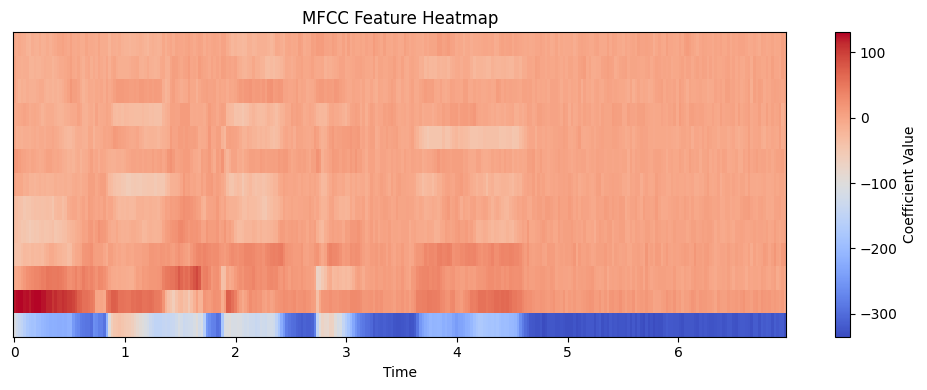

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

mfcc_path = r"C:/Users/Nikhi/OneDrive/Desktop/stuttering/data_sep28k/features/mfcc_static/HeStutters_0_10.npy"
mfcc = np.load(mfcc_path).T   # shape: (n_mfcc, frames)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar(label="Coefficient Value")
plt.title("MFCC Feature Heatmap")
plt.tight_layout()
plt.show()


In [7]:
#pre-compute prosody features:

In [8]:
# precompute_prosody.py
import os, glob, numpy as np, soundfile as sf, librosa
from tqdm import tqdm

BASE = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering"
CLIPS_DIR = os.path.join(BASE, "data_sep28k", "clips_3s")
PROS_DIR  = os.path.join(BASE, "data_sep28k", "features", "prosody")
os.makedirs(PROS_DIR, exist_ok=True)

SR = 16000
WIN = 400          # 25 ms
HOP = 160          # 10 ms

for wav_path in tqdm(glob.glob(os.path.join(CLIPS_DIR, "**", "*.wav"), recursive=True)):
    cid = os.path.splitext(os.path.basename(wav_path))[0]
    out_path = os.path.join(PROS_DIR, f"{cid}_prosody.npy")
    if os.path.exists(out_path):
        continue

    try:
        wav, sr = sf.read(wav_path)
        if wav.ndim > 1:
            wav = wav.mean(axis=1)
        if sr != SR:
            wav = librosa.resample(wav, orig_sr=sr, target_sr=SR)

        # RMS energy and pitch (f0)
        rms = librosa.feature.rms(y=wav, frame_length=WIN, hop_length=HOP, center=True).squeeze(0)
        f0, voiced, _ = librosa.pyin(
            wav, fmin=50, fmax=300, sr=SR, frame_length=WIN, hop_length=HOP, center=True
        )
        f0 = np.nan_to_num(f0, nan=0.0)

        pros = np.stack([f0, rms], axis=1).astype(np.float32)
        # per-clip z-norm
        mu, sigma = pros.mean(0, keepdims=True), pros.std(0, keepdims=True) + 1e-8
        pros = (pros - mu) / sigma
        np.save(out_path, pros)
    except Exception as e:
        print(f"{wav_path}: {e}")


  0%|                                                                                                                              | 0/20906 [00:00<?, ?it/s]C:\Users\Nikhi\AppData\Local\Temp\ipykernel_14244\3350710583.py:29: UserWarning: With fmin=50.000, sr=16000 and frame_length=400, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=80.000 or frame_length=641.
  f0, voiced, _ = librosa.pyin(
 20%|██████████████████████▉                                                                                          | 4245/20906 [30:36<5:46:47,  1.25s/it]C:\Users\Nikhi\AppData\Local\Temp\ipykernel_14244\3350710583.py:29: UserWarning: With fmin=50.000, sr=16000 and frame_length=400, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=80.000 or frame_length=641.
  f0, voiced, _ = librosa.pyin(
100%|█████████████████████████████████████████████████████████

# test train split as bper ep_d

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

groups = labels_df.set_index("clip_id").loc[valid_ids, "EpId"]
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(splitter.split(valid_ids, groups=groups))
train_ids = [valid_ids[i] for i in train_idx]
val_ids   = [valid_ids[i] for i in val_idx]


# BiLSTM + MIL training pipeline --> with GPU

In [13]:
import os, glob, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
BASE = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering"
LABEL_CSV = os.path.join(BASE, "SEP-28k_labels.csv")
MFCC_DIR  = os.path.join(BASE, "data_sep28k", "features", "mfcc_static")  # (T,13)
W2V2_DIR  = os.path.join(BASE, "data_sep28k", "features", "wav2vec2")     # (T,768)
PROS_DIR  = os.path.join(BASE, "data_sep28k", "features", "prosody_new")      # (T,2)

label_cols = ["Prolongation", "Block", "SoundRep", "WordRep"]
NUM_LABELS = len(label_cols)

hidden_size = 256
num_layers  = 2
dropout     = 0.3
batch_size  = 16
epochs      = 10
lr          = 3e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Using device:", device)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def linear_time_resize(x: np.ndarray, tgt_len: int) -> np.ndarray:
    if x.shape[0] == tgt_len:
        return x
    src_idx = np.linspace(0, x.shape[0]-1, x.shape[0])
    tgt_idx = np.linspace(0, x.shape[0]-1, tgt_len)
    return np.stack([np.interp(tgt_idx, src_idx, x[:, d]) for d in range(x.shape[1])], 1).astype(np.float32)

# ---------------------------------------------------------
# ATTENTION POOLING + LOSS
# ---------------------------------------------------------
class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)
    
    def forward(self, logits, mask):
        attn_score = self.attn(logits).squeeze(-1)       # (B,T)
        attn_score = attn_score.masked_fill(~mask, -1e4) # use -1e4 to avoid float16 overflow
        attn_w = F.softmax(attn_score, dim=1)
        probs = torch.sigmoid(logits)
        pooled = torch.sum(probs * attn_w.unsqueeze(-1), dim=1)
        return torch.clamp(pooled, 1e-6, 1 - 1e-6)


def bce_with_pos_weight(p_clip, y, pos_weight):
    eps = 1e-6
    p = torch.clamp(p_clip, eps, 1.0 - eps)
    loss_pos = -y * torch.log(p) * pos_weight
    loss_neg = -(1-y) * torch.log(1-p)
    return (loss_pos + loss_neg).mean()



Using device: cuda


In [14]:

# ---------------------------------------------------------
# MODEL
# ---------------------------------------------------------
class BiLSTM_Seq(nn.Module):
    def __init__(self, input_dim, hidden=256, layers=2, dropout=0.3, num_labels=4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden, num_layers=layers,
            batch_first=True, bidirectional=True, dropout=dropout)
        self.proj = nn.Linear(hidden*2, num_labels)
        self.pool = AttentionPool(num_labels)
        nn.init.normal_(self.proj.weight, mean=0.0, std=0.01)
        nn.init.constant_(self.proj.bias, 0.0)

    def forward(self, x, mask):
        lengths = mask.sum(1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        out_packed, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out_packed, batch_first=True, total_length=x.size(1))
        logits = self.proj(out)
        pooled = self.pool(logits, mask)
        return logits, pooled


# ---------------------------------------------------------
# DATASET + COLLATE
# ---------------------------------------------------------
class SeqFeatureDataset(Dataset):
    def __init__(self, ids, label_dict):
        self.ids, self.label_dict = ids, label_dict
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        cid = self.ids[idx]; show, ep, clip = cid.split("_")
        mfcc = np.load(os.path.join(MFCC_DIR, f"{cid}.npy")).astype(np.float32)
        T = mfcc.shape[0]
        w2v  = np.load(os.path.join(W2V2_DIR, f"{cid}_frame.npy")).astype(np.float32)
        pros = np.load(os.path.join(PROS_DIR,  f"{cid}_prosody.npy")).astype(np.float32)
        w2v, pros = linear_time_resize(w2v, T), linear_time_resize(pros, T)
        x = np.concatenate([mfcc, w2v, pros], 1)
        mu, sigma = x.mean(0, keepdims=True), x.std(0, keepdims=True)+1e-8
        x = (x - mu) / sigma
        y = np.array(self.label_dict[cid], np.float32)
        return {"x": torch.from_numpy(x), "y": torch.from_numpy(y), "len": T, "id": cid}

def pad_collate(batch):
    xs = [b["x"] for b in batch]; ys = [b["y"] for b in batch]; lens = [b["len"] for b in batch]
    xs_pad = pad_sequence(xs, batch_first=True)
    ys = torch.stack(ys)
    masks = torch.zeros(len(batch), xs_pad.size(1), dtype=torch.bool)
    for i,L in enumerate(lens): masks[i,:L]=True
    return {"x":xs_pad,"y":ys,"mask":masks,"ids":[b['id'] for b in batch]}

In [15]:

# ---------------------------------------------------------
# LABELS + VALID IDS
# ---------------------------------------------------------
labels_df = pd.read_csv(LABEL_CSV)
labels_df["clip_id"] = labels_df["Show"].astype(str).str.strip()+"_"+labels_df["EpId"].astype(str)+"_"+labels_df["ClipId"].astype(str)
def make_label(r): return [int(r[c]>0) for c in label_cols]
label_dict = {r["clip_id"]: make_label(r) for _,r in labels_df.iterrows()}

mfcc_ids = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(MFCC_DIR,"*.npy"))}
w2v_ids  = {os.path.basename(p).replace("_frame.npy","") for p in glob.glob(os.path.join(W2V2_DIR,"*_frame.npy"))}
pros_ids = {os.path.basename(p).replace("_prosody.npy","") for p in glob.glob(os.path.join(PROS_DIR,"*_prosody.npy"))}
valid_ids = sorted(list(set(label_dict.keys()) & mfcc_ids & w2v_ids & pros_ids))
train_ids, val_ids = train_test_split(valid_ids, test_size=0.2, random_state=42)
print("Train:",len(train_ids),"Val:",len(val_ids))


Train: 16707 Val: 4177


In [16]:
# ---------------------------------------------------------
# LOADERS  (with WeightedRandomSampler)
# ---------------------------------------------------------
train_ds, val_ds = SeqFeatureDataset(train_ids, label_dict), SeqFeatureDataset(val_ids, label_dict)

# Weighted sampling to upsample stuttered clips
from torch.utils.data import WeightedRandomSampler
all_y = np.stack([label_dict[c] for c in train_ids], 0).astype(np.float32)
sample_weights = np.clip(all_y.sum(1) + 1, 1, 5)  # higher weight for clips with stutter
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_ids), replacement=True)

train_loader = DataLoader(
    train_ds, batch_size=batch_size, sampler=sampler,
    num_workers=0, pin_memory=False, persistent_workers=False,
    collate_fn=pad_collate
)
val_loader = DataLoader(
    val_ds, batch_size=batch_size, shuffle=False,
    num_workers=0, pin_memory=False, persistent_workers=False,
    collate_fn=pad_collate
)




In [17]:
# ---------------------------------------------------------
# MODEL + LOSS SETUP (BCEWithLogitsLoss + scheduler)
# ---------------------------------------------------------
all_y = np.stack([label_dict[c] for c in train_ids], 0).astype(np.float32)
pos_ratio = all_y.mean(0) + 1e-6
pos_weight = torch.tensor(np.clip((1 - pos_ratio) / pos_ratio, 1, 10),
                          dtype=torch.float32, device=device)

model = BiLSTM_Seq(13 + 768 + 2, hidden_size, num_layers, dropout, NUM_LABELS).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)


# ---------------------------------------------------------
# EVALUATION FUNCTION (per-epoch metrics)
# ---------------------------------------------------------
def evaluate_metrics(model, loader):
    model.eval(); y_true=[]; y_pred=[]
    with torch.no_grad():
        for batch in loader:
            x=batch["x"].to(device,non_blocking=True)
            y=batch["y"].to(device,non_blocking=True)
            mask=batch["mask"].to(device,non_blocking=True)
            with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
                p_clip = mil_noisy_or_pool(model(x,mask), mask)
            y_true.append(y.cpu().numpy()); y_pred.append(p_clip.cpu().numpy())
    y_true, y_pred = np.vstack(y_true), np.vstack(y_pred)
    y_hat = (y_pred>0.5).astype(int)
    p,r,f1,_ = precision_recall_fscore_support(y_true,y_hat,average=None,zero_division=0)
    print("\nPer-label metrics:")
    for i,lbl in enumerate(label_cols):
        print(f"{lbl:15s}  P={p[i]:.3f}  R={r[i]:.3f}  F1={f1[i]:.3f}")
    print(f"Macro F1 = {f1.mean():.3f}\n")
    return f1.mean()

C:\Users\Nikhi\AppData\Local\Temp\ipykernel_31016\494723683.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [18]:
# ---------------------------------------------------------
# TRAIN LOOP (GPU + AMP, attention pooling, scheduler)
# ---------------------------------------------------------
for epoch in range(1, 31):  # train longer
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch} [train]"):
        x = batch["x"].to(device, non_blocking=True)
        y = batch["y"].to(device, non_blocking=True)
        mask = batch["mask"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(device.type=="cuda")):   # new syntax
            logits, p_clip = model(x, mask)
            loss = criterion(p_clip.logit(), y)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    print(f"Epoch {epoch} – Train loss: {total_loss / len(train_loader):.4f}")

    # ------------------ Validation ------------------
    model.eval(); val_loss=0; y_true=[]; y_pred=[]
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch} [val]"):
            x=batch["x"].to(device, non_blocking=True)
            y=batch["y"].to(device, non_blocking=True)
            mask=batch["mask"].to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=(device.type=="cuda")):
                logits, p_clip = model(x, mask)
                loss = criterion(p_clip.logit(), y)
            val_loss += loss.item()
            y_true.append(y.cpu().numpy())
            y_pred.append(p_clip.cpu().numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)
    y_hat = (y_pred > 0.5).astype(int)

    p, r, f1, _ = precision_recall_fscore_support(y_true, y_hat, average=None, zero_division=0)
    macro_f1 = f1.mean()
    print(f"Epoch {epoch} – Val loss: {val_loss / len(val_loader):.4f}, Macro F1={macro_f1:.3f}")
    scheduler.step(macro_f1)
# ---------------------------------------------------------
# 👇 Add this after the training loop finishes 👇
# ---------------------------------------------------------
print("\n\n==== FINAL EVALUATION ON VALIDATION SET ====\n")

model.eval(); y_true = []; y_pred = []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="[Final Evaluation]", ncols=100):
        x = batch["x"].to(device, non_blocking=True)
        y = batch["y"].to(device, non_blocking=True)
        mask = batch["mask"].to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(device.type=="cuda")):
            logits, p_clip = model(x, mask)
        y_true.append(y.cpu().numpy())
        y_pred.append(p_clip.cpu().numpy())

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)
y_hat = (y_pred > 0.5).astype(int)

from sklearn.metrics import precision_recall_fscore_support, classification_report, multilabel_confusion_matrix

# --- Macro F1 ---
p, r, f1, _ = precision_recall_fscore_support(y_true, y_hat, average=None, zero_division=0)
macro_f1 = f1.mean()
print(f"\nFinal Macro F1: {macro_f1:.3f}\n")

# --- Classification report ---
print("Classification Report:")
print(classification_report(y_true, y_hat, target_names=label_cols, zero_division=0))

# --- Confusion matrices ---
cms = multilabel_confusion_matrix(y_true, y_hat)
for i, lbl in enumerate(label_cols):
    tn, fp, fn, tp = cms[i].ravel()
    print(f"\n{lbl} Confusion Matrix:")
    print(f"[[TN={tn:5d}  FP={fp:5d}]")
    print(f" [FN={fn:5d}  TP={tp:5d}]]")
    prec = tp / (tp + fp + 1e-6)
    rec  = tp / (tp + fn + 1e-6)
    f1s  = 2*prec*rec / (prec + rec + 1e-6)
    print(f"Precision={prec:.3f}  Recall={rec:.3f}  F1={f1s:.3f}")
print("\n" + "-"*60 + "\n")


Epoch 1 [train]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [08:05<00:00,  2.15it/s]


Epoch 1 – Train loss: 0.9775


Epoch 1 [val]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:23<00:00,  1.29it/s]


Epoch 1 – Val loss: 0.9169, Macro F1=0.493


Epoch 2 [train]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:20<00:00,  2.37it/s]


...

Epoch 30 – Train loss: 0.0328


Epoch 30 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [02:46<00:00,  1.57it/s]


Epoch 30 – Val loss: 3.3608, Macro F1=0.460


==== FINAL EVALUATION ON VALIDATION SET ====



[Final Evaluation]: 100%|█████████████████████████████████████████| 262/262 [01:01<00:00,  4.25it/s]


Final Macro F1: 0.460

Classification Report:
              precision    recall  f1-score   support

Prolongation       0.53      0.46      0.49      1257
       Block       0.51      0.48      0.49      1764
    SoundRep       0.49      0.38      0.43       864
     WordRep       0.49      0.38      0.43       756

   micro avg       0.51      0.44      0.47      4641
   macro avg       0.50      0.42      0.46      4641
weighted avg       0.51      0.44      0.47      4641
 samples avg       0.34      0.31      0.31      4641


Prolongation Confusion Matrix:
[[TN= 2397  FP=  523]
 [FN=  673  TP=  584]]
Precision=0.528  Recall=0.465  F1=0.494

Block Confusion Matrix:
[[TN= 1597  FP=  816]
 [FN=  925  TP=  839]]
Precision=0.507  Recall=0.476  F1=0.491

SoundRep Confusion Matrix:
[[TN= 2975  FP=  338]
 [FN=  539  TP=  325]]
Precision=0.490  Recall=0.376  F1=0.426

WordRep Confusion Matrix:
[[TN= 3124  FP=  297]
 [FN=  468  TP=  288]]
Precision=0.492  Recall=0.381  F1=0.430

-----------

Epoch 1 [train]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [08:05<00:00,  2.15it/s]
Epoch 1 – Train loss: 0.9775
Epoch 1 [val]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:23<00:00,  1.29it/s]
Epoch 1 – Val loss: 0.9169, Macro F1=0.493
Epoch 2 [train]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:20<00:00,  2.37it/s]
Epoch 2 – Train loss: 0.9042
Epoch 2 [val]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:21<00:00,  1.30it/s]
Epoch 2 – Val loss: 0.9151, Macro F1=0.509
Epoch 3 [train]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:00<00:00,  2.49it/s]
Epoch 3 – Train loss: 0.8355
Epoch 3 [val]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:21<00:00,  1.30it/s]
Epoch 3 – Val loss: 0.8974, Macro F1=0.512
Epoch 4 [train]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [06:53<00:00,  2.53it/s]
Epoch 4 – Train loss: 0.7807
Epoch 4 [val]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:22<00:00,  1.30it/s]
Epoch 4 – Val loss: 0.9049, Macro F1=0.518
Epoch 5 [train]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:01<00:00,  2.48it/s]
Epoch 5 – Train loss: 0.7318
Epoch 5 [val]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:20<00:00,  1.30it/s]
Epoch 5 – Val loss: 0.9406, Macro F1=0.522
Epoch 6 [train]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:04<00:00,  2.46it/s]
Epoch 6 – Train loss: 0.6676
Epoch 6 [val]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:21<00:00,  1.30it/s]
Epoch 6 – Val loss: 0.9723, Macro F1=0.524
Epoch 7 [train]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:09<00:00,  2.43it/s]
Epoch 7 – Train loss: 0.6376
Epoch 7 [val]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:20<00:00,  1.31it/s]
Epoch 7 – Val loss: 1.0484, Macro F1=0.521
Epoch 8 [train]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [06:57<00:00,  2.50it/s]
Epoch 8 – Train loss: 0.5810
Epoch 8 [val]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:20<00:00,  1.31it/s]
Epoch 8 – Val loss: 1.1246, Macro F1=0.520
Epoch 9 [train]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:04<00:00,  2.46it/s]
Epoch 9 – Train loss: 0.5945
Epoch 9 [val]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:20<00:00,  1.31it/s]
Epoch 9 – Val loss: 1.0464, Macro F1=0.516
Epoch 10 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [06:56<00:00,  2.51it/s]
Epoch 10 – Train loss: 0.5577
Epoch 10 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:23<00:00,  1.29it/s]
Epoch 10 – Val loss: 1.1781, Macro F1=0.504
Epoch 11 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:33<00:00,  2.31it/s]
Epoch 11 – Train loss: 0.4678
Epoch 11 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:17<00:00,  1.33it/s]
Epoch 11 – Val loss: 1.2745, Macro F1=0.504
Epoch 12 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:01<00:00,  2.48it/s]
Epoch 12 – Train loss: 0.4042
Epoch 12 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:21<00:00,  1.30it/s]
Epoch 12 – Val loss: 1.4241, Macro F1=0.501
Epoch 13 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:04<00:00,  2.46it/s]
Epoch 13 – Train loss: 0.3717
Epoch 13 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:21<00:00,  1.30it/s]
Epoch 13 – Val loss: 1.3529, Macro F1=0.472
Epoch 14 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:01<00:00,  2.48it/s]
Epoch 14 – Train loss: 0.3624
Epoch 14 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:20<00:00,  1.30it/s]
Epoch 14 – Val loss: 1.6909, Macro F1=0.499
Epoch 15 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [06:59<00:00,  2.49it/s]
Epoch 15 – Train loss: 0.2466
Epoch 15 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:21<00:00,  1.30it/s]
Epoch 15 – Val loss: 1.8429, Macro F1=0.494
Epoch 16 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:29<00:00,  2.33it/s]
Epoch 16 – Train loss: 0.1934
Epoch 16 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:21<00:00,  1.30it/s]
Epoch 16 – Val loss: 2.0231, Macro F1=0.492
Epoch 17 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:01<00:00,  2.48it/s]
Epoch 17 – Train loss: 0.1769
Epoch 17 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:20<00:00,  1.30it/s]
Epoch 17 – Val loss: 2.0578, Macro F1=0.484
Epoch 18 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:08<00:00,  2.44it/s]
Epoch 18 – Train loss: 0.1578
Epoch 18 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:21<00:00,  1.30it/s]
Epoch 18 – Val loss: 2.2583, Macro F1=0.482
Epoch 19 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:01<00:00,  2.48it/s]
Epoch 19 – Train loss: 0.1164
Epoch 19 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:20<00:00,  1.31it/s]
Epoch 19 – Val loss: 2.4228, Macro F1=0.476
Epoch 20 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:06<00:00,  2.45it/s]
Epoch 20 – Train loss: 0.0978
Epoch 20 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:21<00:00,  1.30it/s]
Epoch 20 – Val loss: 2.5736, Macro F1=0.471
Epoch 21 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:13<00:00,  2.41it/s]
Epoch 21 – Train loss: 0.0900
Epoch 21 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:09<00:00,  1.38it/s]
Epoch 21 – Val loss: 2.5905, Macro F1=0.477
Epoch 22 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:46<00:00,  2.24it/s]
Epoch 22 – Train loss: 0.0810
Epoch 22 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [01:26<00:00,  3.04it/s]
Epoch 22 – Val loss: 2.7987, Macro F1=0.474
Epoch 23 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:09<00:00,  2.43it/s]
Epoch 23 – Train loss: 0.0661
Epoch 23 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [02:01<00:00,  2.15it/s]
Epoch 23 – Val loss: 2.8882, Macro F1=0.465
Epoch 24 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:24<00:00,  2.35it/s]
Epoch 24 – Train loss: 0.0559
Epoch 24 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [02:15<00:00,  1.94it/s]
Epoch 24 – Val loss: 3.0309, Macro F1=0.467
Epoch 25 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [08:13<00:00,  2.12it/s]
Epoch 25 – Train loss: 0.0506
Epoch 25 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [02:01<00:00,  2.15it/s]
Epoch 25 – Val loss: 3.0426, Macro F1=0.460
Epoch 26 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:33<00:00,  2.30it/s]
Epoch 26 – Train loss: 0.0457
Epoch 26 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [02:09<00:00,  2.03it/s]
Epoch 26 – Val loss: 3.2016, Macro F1=0.465
Epoch 27 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:48<00:00,  2.23it/s]
Epoch 27 – Train loss: 0.0419
Epoch 27 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [02:10<00:00,  2.01it/s]
Epoch 27 – Val loss: 3.2380, Macro F1=0.460
Epoch 28 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [07:49<00:00,  2.22it/s]
Epoch 28 – Train loss: 0.0371
Epoch 28 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [02:10<00:00,  2.00it/s]
Epoch 28 – Val loss: 3.2788, Macro F1=0.464
Epoch 29 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [10:05<00:00,  1.73it/s]
Epoch 29 – Train loss: 0.0346
Epoch 29 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [03:17<00:00,  1.33it/s]
Epoch 29 – Val loss: 3.2926, Macro F1=0.465
Epoch 30 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [08:39<00:00,  2.01it/s]
Epoch 30 – Train loss: 0.0328
Epoch 30 [val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [02:46<00:00,  1.57it/s]
Epoch 30 – Val loss: 3.3608, Macro F1=0.460


==== FINAL EVALUATION ON VALIDATION SET ====

[Final Evaluation]: 100%|█████████████████████████████████████████| 262/262 [01:01<00:00,  4.25it/s]

Final Macro F1: 0.460

Classification Report:
              precision    recall  f1-score   support

Prolongation       0.53      0.46      0.49      1257
       Block       0.51      0.48      0.49      1764
    SoundRep       0.49      0.38      0.43       864
     WordRep       0.49      0.38      0.43       756

   micro avg       0.51      0.44      0.47      4641
   macro avg       0.50      0.42      0.46      4641
weighted avg       0.51      0.44      0.47      4641
 samples avg       0.34      0.31      0.31      4641


Prolongation Confusion Matrix:
[[TN= 2397  FP=  523]
 [FN=  673  TP=  584]]
Precision=0.528  Recall=0.465  F1=0.494

Block Confusion Matrix:
[[TN= 1597  FP=  816]
 [FN=  925  TP=  839]]
Precision=0.507  Recall=0.476  F1=0.491

SoundRep Confusion Matrix:
[[TN= 2975  FP=  338]
 [FN=  539  TP=  325]]
Precision=0.490  Recall=0.376  F1=0.426

WordRep Confusion Matrix:
[[TN= 3124  FP=  297]
 [FN=  468  TP=  288]]
Precision=0.492  Recall=0.381  F1=0.430

------------------------------------------------------------

# ABLATION

In [4]:
import os, glob, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
BASE = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering"
LABEL_CSV = os.path.join(BASE, "SEP-28k_labels.csv")
MFCC_DIR  = os.path.join(BASE, "data_sep28k", "features", "mfcc_static")  # (T,13)
W2V2_DIR  = os.path.join(BASE, "data_sep28k", "features", "wav2vec2")     # (T,768)
PROS_DIR  = os.path.join(BASE, "data_sep28k", "features", "prosody_new")      # (T,2)

label_cols = ["Prolongation", "Block", "SoundRep", "WordRep"]
NUM_LABELS = len(label_cols)

hidden_size = 256
num_layers  = 2
dropout     = 0.3
batch_size  = 16
epochs      = 10
lr          = 3e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Using device:", device)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def linear_time_resize(x: np.ndarray, tgt_len: int) -> np.ndarray:
    if x.shape[0] == tgt_len:
        return x
    src_idx = np.linspace(0, x.shape[0]-1, x.shape[0])
    tgt_idx = np.linspace(0, x.shape[0]-1, tgt_len)
    return np.stack([np.interp(tgt_idx, src_idx, x[:, d]) for d in range(x.shape[1])], 1).astype(np.float32)

# ---------------------------------------------------------
# ATTENTION POOLING + LOSS
# ---------------------------------------------------------
class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)
    
    def forward(self, logits, mask):
        attn_score = self.attn(logits).squeeze(-1)       # (B,T)
        attn_score = attn_score.masked_fill(~mask, -1e4) # use -1e4 to avoid float16 overflow
        attn_w = F.softmax(attn_score, dim=1)
        probs = torch.sigmoid(logits)
        pooled = torch.sum(probs * attn_w.unsqueeze(-1), dim=1)
        return torch.clamp(pooled, 1e-6, 1 - 1e-6)


def bce_with_pos_weight(p_clip, y, pos_weight):
    eps = 1e-6
    p = torch.clamp(p_clip, eps, 1.0 - eps)
    loss_pos = -y * torch.log(p) * pos_weight
    loss_neg = -(1-y) * torch.log(1-p)
    return (loss_pos + loss_neg).mean()

Using device: cuda


In [5]:
# ---------------------------------------------------------
# MODEL
# ---------------------------------------------------------
class BiLSTM_Seq(nn.Module):
    def __init__(self, input_dim, hidden=256, layers=2, dropout=0.3, num_labels=4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden, num_layers=layers,
            batch_first=True, bidirectional=True, dropout=dropout)
        self.proj = nn.Linear(hidden*2, num_labels)
        self.pool = AttentionPool(num_labels)
        nn.init.normal_(self.proj.weight, mean=0.0, std=0.01)
        nn.init.constant_(self.proj.bias, 0.0)

    def forward(self, x, mask):
        lengths = mask.sum(1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        out_packed, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out_packed, batch_first=True, total_length=x.size(1))
        logits = self.proj(out)
        pooled = self.pool(logits, mask)
        return logits, pooled


In [6]:
class SeqFeatureDataset_AB(Dataset):
    def __init__(self, ids, label_dict, mode="mfcc"):
        self.ids, self.label_dict = ids, label_dict
        self.mode = mode.lower()

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        cid = self.ids[idx]
        mfcc = np.load(os.path.join(MFCC_DIR, f"{cid}.npy")).astype(np.float32)
        T = mfcc.shape[0]

        if self.mode == "mfcc":
            x = mfcc

        elif self.mode == "wav2vec":
            w2v = np.load(os.path.join(W2V2_DIR, f"{cid}_frame.npy")).astype(np.float32)
            x = linear_time_resize(w2v, T)

        elif self.mode == "mfcc+wav2vec":
            w2v = np.load(os.path.join(W2V2_DIR, f"{cid}_frame.npy")).astype(np.float32)
            w2v = linear_time_resize(w2v, T)
            x = np.concatenate([mfcc, w2v], axis=1)

        mu, sigma = x.mean(0, keepdims=True), x.std(0, keepdims=True)+1e-8
        x = (x - mu) / sigma
        y = np.array(self.label_dict[cid], np.float32)
        return {"x": torch.from_numpy(x), "y": torch.from_numpy(y), "len": T}


In [7]:
def pad_collate(batch):
    xs = [b["x"] for b in batch]; ys = [b["y"] for b in batch]; lens = [b["len"] for b in batch]
    xs_pad = pad_sequence(xs, batch_first=True)
    ys = torch.stack(ys)
    masks = torch.zeros(len(batch), xs_pad.size(1), dtype=torch.bool)
    for i,L in enumerate(lens): masks[i,:L]=True
    return {"x":xs_pad,"y":ys,"mask":masks}


In [8]:
labels_df = pd.read_csv(LABEL_CSV)
labels_df["clip_id"] = labels_df["Show"].astype(str).str.strip()+"_"+labels_df["EpId"].astype(str)+"_"+labels_df["ClipId"].astype(str)
def make_label(r): return [int(r[c]>0) for c in label_cols]
label_dict = {r["clip_id"]: make_label(r) for _,r in labels_df.iterrows()}

mfcc_ids = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(MFCC_DIR,"*.npy"))}
w2v_ids  = {os.path.basename(p).replace("_frame.npy","") for p in glob.glob(os.path.join(W2V2_DIR,"*_frame.npy"))}
valid_ids = sorted(list(set(label_dict.keys()) & mfcc_ids & w2v_ids))

from sklearn.model_selection import train_test_split
train_ids, val_ids = train_test_split(valid_ids, test_size=0.2, random_state=42)


In [9]:
def train_and_eval(mode, input_dim):
    print(f"\n{'='*80}\nRunning Ablation: {mode.upper()}\n{'='*80}")

    # --- data setup (same as before) ---
    train_ds = SeqFeatureDataset_AB(train_ids, label_dict, mode=mode)
    val_ds   = SeqFeatureDataset_AB(val_ids, label_dict, mode=mode)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=pad_collate)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=pad_collate)

    all_y = np.stack([label_dict[c] for c in train_ids], 0).astype(np.float32)
    pos_ratio = all_y.mean(0) + 1e-6
    pos_weight = torch.tensor(np.clip((1 - pos_ratio) / pos_ratio, 1, 10),
                              dtype=torch.float32, device=device)

    model = BiLSTM_Seq(input_dim, hidden_size, num_layers, dropout, NUM_LABELS).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # --- training loop (early stopping etc.) ---
    best_val_metric = -float("inf")
    best_model_state = None
    patience = 5
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for batch in tqdm(train_loader, desc=f"[{mode}] Epoch {epoch} [train]"):
            x, y, mask = batch["x"].to(device), batch["y"].to(device), batch["mask"].to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                logits, p_clip = model(x, mask)
                loss = criterion(p_clip.logit(), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item()
        avg_train = total_loss / len(train_loader)
        print(f"Epoch {epoch} – Train loss: {avg_train:.4f}")

        # --- validation ---
        model.eval()
        val_loss, y_true, y_pred = 0.0, [], []
        with torch.no_grad():
            for batch in val_loader:
                x, y, mask = batch["x"].to(device), batch["y"].to(device), batch["mask"].to(device)
                with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                    logits, p_clip = model(x, mask)
                    loss = criterion(p_clip.logit(), y)
                val_loss += loss.item()
                y_true.append(y.cpu().numpy())
                y_pred.append(p_clip.cpu().numpy())
        val_loss /= len(val_loader)
        y_true, y_pred = np.vstack(y_true), np.vstack(y_pred)
        macro_f1 = precision_recall_fscore_support(
            y_true, (y_pred > 0.5).astype(int), average="macro", zero_division=0
        )[2]
        print(f"Epoch {epoch} – Val loss: {val_loss:.4f}  Macro F1: {macro_f1:.3f}")

        # --- early stopping ---
        if macro_f1 > best_val_metric:
            best_val_metric = macro_f1
            best_model_state = model.state_dict()
            epochs_no_improve = 0
            print("New best model saved.")
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break

    # --- restore best model ---
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Restored best model (Macro F1={best_val_metric:.3f}).")

    # --- final evaluation (save preds) ---
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"[{mode}] Final Eval"):
            x, y, mask = batch["x"].to(device), batch["y"].to(device), batch["mask"].to(device)
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                _, p_clip = model(x, mask)
            y_true.append(y.cpu().numpy())
            y_pred.append(p_clip.cpu().numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)
    y_hat = (y_pred > 0.5).astype(int)

    # --- save predictions for threshold tuning ---
    out_path = f"preds_{mode}.npz"
    np.savez(out_path, y_true=y_true, y_pred=y_pred)
    print(f"💾 Saved raw predictions to {out_path}")

    macro_f1 = precision_recall_fscore_support(y_true, y_hat, average="macro", zero_division=0)[2]
    print(f"\nFinal Macro F1 ({mode}): {macro_f1:.3f}")
    print("=" * 80)
    return macro_f1


In [10]:
# MFCC-only
train_and_eval(mode="mfcc", input_dim=13)



Running Ablation: MFCC


[mfcc] Epoch 1 [train]: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [04:15<00:00,  4.10it/s]


Epoch 1 – Train loss: 0.9853
Epoch 1 – Val loss: 0.9691  Macro F1: 0.415
New best model saved.


[mfcc] Epoch 2 [train]: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [01:36<00:00, 10.80it/s]


Epoch 2 – Train loss: 0.9655
Epoch 2 – Val loss: 0.9545  Macro F1: 0.432
New best model saved.


...

[mfcc] Epoch 10 [train]: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [01:41<00:00, 10.26it/s]


Epoch 10 – Train loss: 0.8282
Epoch 10 – Val loss: 0.8995  Macro F1: 0.497
New best model saved.
Restored best model (Macro F1=0.497).


[mfcc] Final Eval: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [00:11<00:00, 23.73it/s]

💾 Saved raw predictions to preds_mfcc.npz

Final Macro F1 (mfcc): 0.497


0.4974647447542511

In [11]:
# Wav2Vec2-only
train_and_eval(mode="wav2vec", input_dim=768)



Running Ablation: WAV2VEC


[wav2vec] Epoch 1 [train]: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [08:31<00:00,  2.04it/s]


Epoch 1 – Train loss: 0.9065
Epoch 1 – Val loss: 0.8971  Macro F1: 0.504
New best model saved.


[wav2vec] Epoch 2 [train]: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [06:53<00:00,  2.53it/s]


Epoch 2 – Train loss: 0.8519
Epoch 2 – Val loss: 0.8574  Macro F1: 0.509
New best model saved.


...

[wav2vec] Epoch 8 [train]: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [06:10<00:00,  2.82it/s]


Epoch 8 – Train loss: 0.6206
Epoch 8 – Val loss: 0.9398  Macro F1: 0.518
No improvement for 5 epoch(s).
Early stopping triggered.
Restored best model (Macro F1=0.526).


[wav2vec] Final Eval: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 262/262 [00:51<00:00,  5.05it/s]

💾 Saved raw predictions to preds_wav2vec.npz

Final Macro F1 (wav2vec): 0.518


0.5175351841066131

In [12]:

# MFCC + Wav2Vec2
train_and_eval(mode="mfcc+wav2vec", input_dim=13+768)


Running Ablation: MFCC+WAV2VEC


[mfcc+wav2vec] Epoch 1 [train]: 100%|████████████████████████████████████████████████████████████████████████████████████| 1045/1045 [06:06<00:00,  2.85it/s]


Epoch 1 – Train loss: 0.9003
Epoch 1 – Val loss: 0.8631  Macro F1: 0.490
New best model saved.


[mfcc+wav2vec] Epoch 2 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████| 1045/1045 [1:08:27<00:00,  3.93s/it]


Epoch 2 – Train loss: 0.8399
Epoch 2 – Val loss: 0.8447  Macro F1: 0.514
New best model saved.


...

[mfcc+wav2vec] Epoch 10 [train]: 100%|███████████████████████████████████████████████████████████████████████████████████| 1045/1045 [09:10<00:00,  1.90it/s]


Epoch 10 – Train loss: 0.5304
Epoch 10 – Val loss: 1.0329  Macro F1: 0.530
No improvement for 5 epoch(s).
Early stopping triggered.
Restored best model (Macro F1=0.540).


[mfcc+wav2vec] Final Eval: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 262/262 [00:57<00:00,  4.56it/s]

💾 Saved raw predictions to preds_mfcc+wav2vec.npz

Final Macro F1 (mfcc+wav2vec): 0.530


0.5298058434096863

# Re-run all 3 feature types with early stopping

# CALCULATE DELAY METRIC FOR MFCC+WAV2VEC2 

In [3]:
import numpy as np

data = np.load("preds_mfcc+wav2vec.npz")
print(data.files)
# should show: ['y_true', 'y_pred']

y_true, y_pred = data["y_true"], data["y_pred"]
print("Shapes:", y_true.shape, y_pred.shape)


['y_true', 'y_pred']
Shapes: (4177, 4) (4177, 4)


In [4]:
JOINED_CSV = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\SEP-28k_joined_labels_episodes.csv"
import pandas as pd
meta = pd.read_csv(JOINED_CSV)
meta["clip_id"] = meta["Show"].astype(str).str.strip()+"_"+meta["EpId"].astype(str)+"_"+meta["ClipId"].astype(str)


In [5]:
meta

,Show,EpId,ClipId,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,SoundRep,...,Music,NoSpeech,Podcast,Episode,URL,EpID,Start_sec,Stop_sec,Duration_sec,clip_id
0,HeStutters,0,0,31900320,31948320,0,0,0,0,0,...,0,0,He_Stutters_Podcast_â€“_Make_Room_For_The_Stut...,episode-208-with-kelsey-h,https://stutterrockstar.files.wordpress.com/2...,0,1993.77,1996.77,3.0,HeStutters_0_0
1,HeStutters,0,1,31977120,32025120,0,0,0,0,0,...,0,0,He_Stutters_Podcast_â€“_Make_Room_For_The_Stut...,episode-208-with-kelsey-h,https://stutterrockstar.files.wordpress.com/2...,0,1998.57,2001.57,3.0,HeStutters_0_1
2,HeStutters,0,2,34809760,34857760,0,0,0,0,0,...,0,0,He_Stutters_Podcast_â€“_Make_Room_For_The_Stut...,episode-208-with-kelsey-h,https://stutterrockstar.files.wordpress.com/2...,0,2175.61,2178.61,3.0,HeStutters_0_2
3,HeStutters,0,3,35200640,35248640,0,0,1,0,0,...,0,0,He_Stutters_Podcast_â€“_Make_Room_For_The_Stut...,episode-208-with-kelsey-h,https://stutterrockstar.files.wordpress.com/2...,0,2200.04,2203.04,3.0,HeStutters_0_3
4,HeStutters,0,4,35721920,35769920,0,0,0,0,0,...,0,0,He_Stutters_Podcast_â€“_Make_Room_For_The_Stut...,episode-208-with-kelsey-h,https://stutterrockstar.files.wordpress.com/2...,0,2232.62,2235.62,3.0,HeStutters_0_4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28172,WomenWhoStutter,109,35,25793600,25841600,0,0,0,0,0,...,0,0,Women_Who_Stutter_Podcast_â€“_Make_Room_For_Th...,cool148,https://stutterrockstar.files.wordpress.com/2...,109,1612.10,1615.10,3.0,WomenWhoStutter_109_35
28173,WomenWhoStutter,109,36,26168480,26216480,0,0,1,1,3,...,0,0,Women_Who_Stutter_Podcast_â€“_Make_Room_For_Th...,cool148,https://stutterrockstar.files.wordpress.com/2...,109,1635.53,1638.53,3.0,WomenWhoStutter_109_36
28174,WomenWhoStutter,109,37,3569440,3617440,0,0,0,0,0,...,0,0,Women_Who_Stutter_Podcast_â€“_Make_Room_For_Th...,cool148,https://stutterrockstar.files.wordpress.com/2...,109,223.09,226.09,3.0,WomenWhoStutter_109_37
28175,WomenWhoStutter,109,38,28479840,28527840,0,0,1,0,0,...,0,0,Women_Who_Stutter_Podcast_â€“_Make_Room_For_Th...,cool148,https://stutterrockstar.files.wordpress.com/2...,109,1779.99,1782.99,3.0,WomenWhoStutter_109_38


In [6]:
meta = meta.loc[:len(y_pred)-1]   # same order as validation if sequential
meta["Prolongation_prob"] = y_pred[:,0]
meta["Block_prob"]         = y_pred[:,1]
meta["SoundRep_prob"]      = y_pred[:,2]
meta["WordRep_prob"]       = y_pred[:,3]


C:\Users\Nikhi\AppData\Local\Temp\ipykernel_28184\3966858054.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta["Prolongation_prob"] = y_pred[:,0]
C:\Users\Nikhi\AppData\Local\Temp\ipykernel_28184\3966858054.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta["Block_prob"]         = y_pred[:,1]
C:\Users\Nikhi\AppData\Local\Temp\ipykernel_28184\3966858054.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

In [7]:
meta

,Show,EpId,ClipId,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,SoundRep,...,URL,EpID,Start_sec,Stop_sec,Duration_sec,clip_id,Prolongation_prob,Block_prob,SoundRep_prob,WordRep_prob
0,HeStutters,0,0,31900320,31948320,0,0,0,0,0,...,https://stutterrockstar.files.wordpress.com/2...,0,1993.77,1996.77,3.0,HeStutters_0_0,0.323687,0.755837,0.219054,0.007106
1,HeStutters,0,1,31977120,32025120,0,0,0,0,0,...,https://stutterrockstar.files.wordpress.com/2...,0,1998.57,2001.57,3.0,HeStutters_0_1,0.234509,0.749658,0.736137,0.739278
2,HeStutters,0,2,34809760,34857760,0,0,0,0,0,...,https://stutterrockstar.files.wordpress.com/2...,0,2175.61,2178.61,3.0,HeStutters_0_2,0.810550,0.459323,0.040943,0.651555
3,HeStutters,0,3,35200640,35248640,0,0,1,0,0,...,https://stutterrockstar.files.wordpress.com/2...,0,2200.04,2203.04,3.0,HeStutters_0_3,0.205737,0.276096,0.040800,0.955520
4,HeStutters,0,4,35721920,35769920,0,0,0,0,0,...,https://stutterrockstar.files.wordpress.com/2...,0,2232.62,2235.62,3.0,HeStutters_0_4,0.907718,0.436981,0.151501,0.028159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4172,HVSA,2,163,34060160,34108160,0,0,0,0,0,...,https://anchor.fm/s/184c5dac/podcast/play/116...,2,2128.76,2131.76,3.0,HVSA_2_163,0.065409,0.349008,0.029382,0.012890
4173,HVSA,2,164,34191520,34239520,0,0,0,0,0,...,https://anchor.fm/s/184c5dac/podcast/play/116...,2,2136.97,2139.97,3.0,HVSA_2_164,0.531892,0.722241,0.980069,0.938080
4174,HVSA,2,165,34219040,34267040,0,0,0,1,2,...,https://anchor.fm/s/184c5dac/podcast/play/116...,2,2138.69,2141.69,3.0,HVSA_2_165,0.981378,0.784799,0.991834,0.927827
4175,HVSA,2,166,34606400,34654400,0,0,0,0,0,...,https://anchor.fm/s/184c5dac/podcast/play/116...,2,2162.90,2165.90,3.0,HVSA_2_166,0.176412,0.606509,0.073136,0.000701


In [8]:
agg = meta.groupby(["Show","EpId"])[
    ["Prolongation_prob","Block_prob","SoundRep_prob","WordRep_prob"]
].mean().reset_index()


In [9]:
agg

,Show,EpId,Prolongation_prob,Block_prob,SoundRep_prob,WordRep_prob
0,HVSA,0,0.403454,0.512042,0.325176,0.272302
1,HVSA,1,0.390441,0.516999,0.360634,0.250247
2,HVSA,2,0.450796,0.523615,0.348643,0.247490
3,HeStutters,0,0.377412,0.448023,0.232540,0.262791
4,HeStutters,1,0.424034,0.547195,0.353190,0.240721
5,HeStutters,2,0.406293,0.542570,0.370215,0.269954
6,HeStutters,3,0.406788,0.507920,0.288496,0.193502
7,HeStutters,4,0.390284,0.509190,0.319809,0.261546
8,HeStutters,5,0.382119,0.497692,0.277140,0.263934
9,HeStutters,6,0.403079,0.513348,0.333680,0.233494


In [10]:
def compute_delay_metric(df, frame_hop=160, sr=16000, alpha=100):
    """
    df: DataFrame with mean probabilities per clip or speaker.
    Returns: recommended delay (ms) per row.
    """
    # proxy for overall stuttering severity
    df["stutter_intensity"] = df[
        ["Prolongation_prob","Block_prob","SoundRep_prob","WordRep_prob"]
    ].mean(axis=1)

    # proxy for rhythmic irregularity: variance among disfluency types
    df["stutter_var"] = df[
        ["Prolongation_prob","Block_prob","SoundRep_prob","WordRep_prob"]
    ].var(axis=1)

    # combine into rhythmic-delay ratio
    df["delay_ratio"] = (df["stutter_intensity"] + df["stutter_var"]) / 2.0

    # map ratio -> delay (50–200 ms)
    df["delay_ms"] = 50 + 150 * df["delay_ratio"]
    df["delay_ms"] = df["delay_ms"].clip(50, 200)
    return df


In [11]:
df_delay = compute_delay_metric(agg)
print(df_delay[["Show","EpId","delay_ms"]])
df_delay.to_csv("speaker_delay_metrics.csv", index=False)


          Show  EpId   delay_ms
0         HVSA     0  79.182693
1         HVSA     1  79.370705
2         HVSA     2  80.536240
3   HeStutters     0  75.519180
4   HeStutters     1  80.583923
5   HeStutters     2  80.747711
6   HeStutters     3  77.599121
7   HeStutters     4  78.617218
8   HeStutters     5  77.527870
9   HeStutters     6  78.857346
10  HeStutters     7  81.139885
11  HeStutters     8  78.892151
12  HeStutters     9  82.003448
13  HeStutters    10  81.762939
14  HeStutters    11  81.370667
15  HeStutters    12  79.903503
16  HeStutters    13  78.314285
17  HeStutters    14  76.052673
18  HeStutters    15  80.092407
19  HeStutters    16  80.888733
20  HeStutters    17  81.672295
21  HeStutters    18  79.585968
22  HeStutters    19  80.867638
23  HeStutters    20  80.374191
24  HeStutters    21  78.914238
25  HeStutters    22  79.915756
26  HeStutters    23  78.330627


In [12]:
import os

def add_prosody_variance(df, prosody_dir):
    rms_vars = []
    for _, row in df.iterrows():
        show = row["Show"]
        ep   = row["EpId"]
        clip_pattern = f"{show}_{ep}_"
        files = [f for f in os.listdir(prosody_dir) if f.startswith(clip_pattern)]
        rms_var = 0.0
        if files:
            arr = np.load(os.path.join(prosody_dir, files[0]))
            rms_var = np.var(arr[:,1])  # RMS variance
        rms_vars.append(rms_var)
    df["rms_var"] = rms_vars
    df["delay_ms"] += 30 * np.tanh(df["rms_var"])  # adjust by prosodic instability
    df["delay_ms"] = df["delay_ms"].clip(50,200)
    return df

PROS_DIR = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\data_sep28k\features\prosody_new"
df_delay = add_prosody_variance(df_delay, PROS_DIR)
df_delay.to_csv("speaker_delay_metrics_with_prosody.csv", index=False)


In [13]:
df_delay

,Show,EpId,Prolongation_prob,Block_prob,SoundRep_prob,WordRep_prob,stutter_intensity,stutter_var,delay_ratio,delay_ms,rms_var
0,HVSA,0,0.403454,0.512042,0.325176,0.272302,0.378243,0.010859,0.194551,102.029793,0.999943
1,HVSA,1,0.390441,0.516999,0.360634,0.250247,0.379580,0.012029,0.195805,102.218529,1.000000
2,HVSA,2,0.450796,0.523615,0.348643,0.247490,0.392636,0.014514,0.203575,103.384048,0.999999
3,HeStutters,0,0.377412,0.448023,0.232540,0.262791,0.330191,0.010064,0.170128,98.366997,1.000000
4,HeStutters,1,0.424034,0.547195,0.353190,0.240721,0.391285,0.016500,0.203893,103.431740,1.000000
5,HeStutters,2,0.406293,0.542570,0.370215,0.269954,0.397258,0.012712,0.204985,103.595528,0.999999
6,HeStutters,3,0.406788,0.507920,0.288496,0.193502,0.349177,0.018812,0.183994,100.446938,1.000000
7,HeStutters,4,0.390284,0.509190,0.319809,0.261546,0.370207,0.011356,0.190781,101.465042,1.000000
8,HeStutters,5,0.382119,0.497692,0.277140,0.263934,0.355221,0.011817,0.183519,100.375694,1.000000
9,HeStutters,6,0.403079,0.513348,0.333680,0.233494,0.370900,0.013864,0.192382,101.705162,1.000000


# HUMAN-ANNOTATIONS --> DELAY CALCULATION

In [48]:
# delay_metric_human.py
import pandas as pd
import numpy as np

LABEL_CSV = r"C:\Users\Nikhi\OneDrive\Desktop\stuttering\SEP-28k_labels.csv"
SR = 16000

label_cols = ["Prolongation", "Block", "SoundRep", "WordRep"]

def compute_human_delay_metric(label_csv):
    df = pd.read_csv(label_csv)
    df["clip_id"] = (
        df["Show"].astype(str).str.strip() + "_" +
        df["EpId"].astype(str) + "_" +
        df["ClipId"].astype(str)
    )

    # Convert start/stop samples to seconds
    df["Start_sec"] = df["Start"] / SR
    df["Stop_sec"]  = df["Stop"]  / SR
    df["Duration_sec"] = df["Stop_sec"] - df["Start_sec"]

    # Compute intensity and variance per clip
    # Compute intensity and variance per clip (normalized to 0–1)
    df["human_intensity"] = df[label_cols].mean(axis=1) / 3.0
    df["human_var"] = df[label_cols].var(axis=1) / (3.0**2)  # normalize variance as well


    # Combine into rhythmic-delay ratio
    df["human_delay_ratio"] = (df["human_intensity"] + df["human_var"]) / 2.0

    # Map ratio → delay in milliseconds (50–200 ms range)
    df["human_delay_ms"] = 50 + 150 * df["human_delay_ratio"]
    df["human_delay_ms"] = df["human_delay_ms"].clip(50, 200)

    # Aggregate by speaker (optional)
    agg = df.groupby(["Show", "EpId"]).agg({
        "human_delay_ms": "mean",
        "human_intensity": "mean"
    }).reset_index()

    return df, agg

if __name__ == "__main__":
    df, agg = compute_human_delay_metric(LABEL_CSV)
    print(agg)
    agg.to_csv("human_delay_metrics.csv", index=False)


                Show  EpId  human_delay_ms  human_intensity
0               HVSA     0       67.143147         0.161192
1               HVSA     1       64.036643         0.126773
2               HVSA     2       66.229167         0.150000
3               HVSA     3       67.548710         0.157188
4         HeStutters     0       54.270833         0.041667
..               ...   ...             ...              ...
380  WomenWhoStutter   105       62.500000         0.120833
381  WomenWhoStutter   106       60.763889         0.091667
382  WomenWhoStutter   107       60.868056         0.097917
383  WomenWhoStutter   108       66.701389         0.152083
384  WomenWhoStutter   109       61.215278         0.106250

[385 rows x 4 columns]


In [49]:
agg

,Show,EpId,human_delay_ms,human_intensity
0,HVSA,0,67.143147,0.161192
1,HVSA,1,64.036643,0.126773
2,HVSA,2,66.229167,0.150000
3,HVSA,3,67.548710,0.157188
4,HeStutters,0,54.270833,0.041667
...,...,...,...,...
380,WomenWhoStutter,105,62.500000,0.120833
381,WomenWhoStutter,106,60.763889,0.091667
382,WomenWhoStutter,107,60.868056,0.097917
383,WomenWhoStutter,108,66.701389,0.152083


# classification report

In [64]:
# evaluate_preds.py
import numpy as np
from sklearn.metrics import classification_report, multilabel_confusion_matrix, precision_recall_fscore_support

# Load predictions
data = np.load("preds_mfcc+wav2vec.npz")
y_true = data["y_true"]
y_pred = data["y_pred"]

# Threshold probabilities to get binary outputs
THRESH = 0.5  # change later if you tuned thresholds
y_hat = (y_pred > THRESH).astype(int)

# Define label names
label_cols = ["Prolongation", "Block", "SoundRep", "WordRep"]

# Classification report
print("\n=== Classification Report (Threshold = 0.5) ===\n")
print(classification_report(y_true, y_hat, target_names=label_cols, zero_division=0))

# Compute and print confusion matrices per class
cms = multilabel_confusion_matrix(y_true, y_hat)
for i, lbl in enumerate(label_cols):
    tn, fp, fn, tp = cms[i].ravel()
    print(f"\n--- {lbl} Confusion Matrix ---")
    print(f"[[TN={tn:5d}  FP={fp:5d}]")
    print(f" [FN={fn:5d}  TP={tp:5d}]]")

# Optionally compute macro metrics summary
p, r, f1, _ = precision_recall_fscore_support(y_true, y_hat, average=None, zero_division=0)
macro_f1 = f1.mean()
print(f"\nMacro F1 = {macro_f1:.3f}")




=== Classification Report (Threshold = 0.5) ===

              precision    recall  f1-score   support

Prolongation       0.49      0.63      0.55      1257
       Block       0.52      0.62      0.57      1764
    SoundRep       0.42      0.66      0.52       864
     WordRep       0.44      0.55      0.49       756

   micro avg       0.48      0.62      0.54      4641
   macro avg       0.47      0.62      0.53      4641
weighted avg       0.48      0.62      0.54      4641
 samples avg       0.37      0.43      0.37      4641


--- Prolongation Confusion Matrix ---
[[TN= 2078  FP=  842]
 [FN=  464  TP=  793]]

--- Block Confusion Matrix ---
[[TN= 1398  FP= 1015]
 [FN=  667  TP= 1097]]

--- SoundRep Confusion Matrix ---
[[TN= 2539  FP=  774]
 [FN=  292  TP=  572]]

--- WordRep Confusion Matrix ---
[[TN= 2885  FP=  536]
 [FN=  340  TP=  416]]

Macro F1 = 0.530


In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Save classification report
from sklearn.metrics import classification_report
report = classification_report(y_true, y_hat, target_names=label_cols, output_dict=True)
import pandas as pd
pd.DataFrame(report).to_csv("report_mfcc+wav2vec.csv")

# Save confusion matrices as figures
for i, lbl in enumerate(label_cols):
    disp = ConfusionMatrixDisplay(confusion_matrix=cms[i], display_labels=["0","1"])
    disp.plot(cmap="Blues", values_format='d')
    plt.title(f"{lbl} Confusion Matrix (MFCC-only)")
    plt.savefig(f"cm_{lbl}_mfcc.png")
    plt.close()


C:\Users\Nikhi\OneDrive\Desktop\stuttering\stutterenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Nikhi\OneDrive\Desktop\stuttering\stutterenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Nikhi\OneDrive\Desktop\stuttering\stutterenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [67]:
import numpy as np
from sklearn.metrics import f1_score

label_cols = ["Prolongation", "Block", "SoundRep", "WordRep"]

# Load predictions
data = np.load("preds_mfcc+wav2vec.npz")
y_true, y_pred = data["y_true"], data["y_pred"]

best_thresh = {}
for i, lbl in enumerate(label_cols):
    thresholds = np.linspace(0.05, 0.95, 19)
    f1s = [f1_score(y_true[:, i], (y_pred[:, i] > t).astype(int)) for t in thresholds]
    t_best = thresholds[np.argmax(f1s)]
    best_thresh[lbl] = float(t_best)
    print(f"{lbl}: best threshold={t_best:.2f}, max F1={max(f1s):.3f}")

np.savez("best_thresholds_mfcc+wav2vec2.npz", **best_thresh)


Prolongation: best threshold=0.40, max F1=0.557
Block: best threshold=0.30, max F1=0.602
SoundRep: best threshold=0.55, max F1=0.518
WordRep: best threshold=0.60, max F1=0.494


In [68]:
from sklearn.metrics import classification_report, multilabel_confusion_matrix
import pandas as pd

best = np.load("best_thresholds_mfcc+wav2vec2.npz")
thr = np.array([best[l] for l in label_cols])
y_hat = (y_pred > thr).astype(int)

# Classification report
report = classification_report(y_true, y_hat, target_names=label_cols, zero_division=0)
print(report)

# Confusion matrices
cms = multilabel_confusion_matrix(y_true, y_hat)
for i, lbl in enumerate(label_cols):
    tn, fp, fn, tp = cms[i].ravel()
    print(f"\n{lbl} Confusion Matrix mfcc+wav2vec2 (tuned):")
    print(f"[[TN={tn:5d}  FP={fp:5d}]")
    print(f" [FN={fn:5d}  TP={tp:5d}]]")

# Save results
pd.DataFrame(classification_report(y_true, y_hat, target_names=label_cols, output_dict=True)).to_csv("report_mfcc+wav2vec2_tuned.csv")


              precision    recall  f1-score   support

Prolongation       0.46      0.70      0.56      1257
       Block       0.45      0.93      0.60      1764
    SoundRep       0.44      0.63      0.52       864
     WordRep       0.48      0.51      0.49       756

   micro avg       0.45      0.74      0.56      4641
   macro avg       0.46      0.69      0.54      4641
weighted avg       0.45      0.74      0.56      4641
 samples avg       0.41      0.53      0.44      4641


Prolongation Confusion Matrix mfcc+wav2vec2 (tuned):
[[TN= 1883  FP= 1037]
 [FN=  371  TP=  886]]

Block Confusion Matrix mfcc+wav2vec2 (tuned):
[[TN=  379  FP= 2034]
 [FN=  128  TP= 1636]]

SoundRep Confusion Matrix mfcc+wav2vec2 (tuned):
[[TN= 2608  FP=  705]
 [FN=  316  TP=  548]]

WordRep Confusion Matrix mfcc+wav2vec2 (tuned):
[[TN= 3001  FP=  420]
 [FN=  370  TP=  386]]


C:\Users\Nikhi\OneDrive\Desktop\stuttering\stutterenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Nikhi\OneDrive\Desktop\stuttering\stutterenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Nikhi\OneDrive\Desktop\stuttering\stutterenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [69]:
# save_confusion_reports.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    multilabel_confusion_matrix,
    ConfusionMatrixDisplay
)

# ---------------------------------------------------------
# Load predictions and best thresholds
# ---------------------------------------------------------
label_cols = ["Prolongation", "Block", "SoundRep", "WordRep"]

data = np.load("preds_mfcc+wav2vec.npz")
y_true, y_pred = data["y_true"], data["y_pred"]

# Load tuned thresholds (or define manually)
best = np.load("best_thresholds_mfcc+wav2vec2.npz")
thr = np.array([best[l] for l in label_cols])

# Apply thresholds
y_hat = (y_pred > thr).astype(int)

# ---------------------------------------------------------
# Classification report
# ---------------------------------------------------------
report_dict = classification_report(
    y_true, y_hat, target_names=label_cols, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("report_mfcc+wav2vec_tuned.csv")
print("✅ Saved classification report to 'report_mfcc+wav2vec_tuned.csv'")

# ---------------------------------------------------------
# Confusion matrices
# ---------------------------------------------------------
cms = multilabel_confusion_matrix(y_true, y_hat)

for i, lbl in enumerate(label_cols):
    disp = ConfusionMatrixDisplay(confusion_matrix=cms[i], display_labels=["0", "1"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{lbl} Confusion Matrix (mfcc+wav2vec, tuned)")
    plt.tight_layout()
    plt.savefig(f"cm_{lbl}_mfcc+wav2vec_tuned.png", dpi=300)
    plt.close()

print("✅ Saved confusion matrices as PNG files.")


✅ Saved classification report to 'report_mfcc+wav2vec_tuned.csv'
✅ Saved confusion matrices as PNG files.


In [70]:
#all 3 feature files:

In [72]:
!pip install seaborn

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define metrics manually from your report
label_cols = ["Prolongation", "Block", "SoundRep", "WordRep"]

precision = [0.528, 0.507, 0.490, 0.492]
recall    = [0.465, 0.476, 0.376, 0.381]
f1_score  = [0.494, 0.491, 0.426, 0.430]

# Macro averages (optional)
macro_avg = {
    "precision": np.mean(precision),
    "recall": np.mean(recall),
    "f1": np.mean(f1_score)
}
print("Macro averages:", macro_avg)


Macro averages: {'precision': np.float64(0.5042500000000001), 'recall': np.float64(0.42450000000000004), 'f1': np.float64(0.46025)}


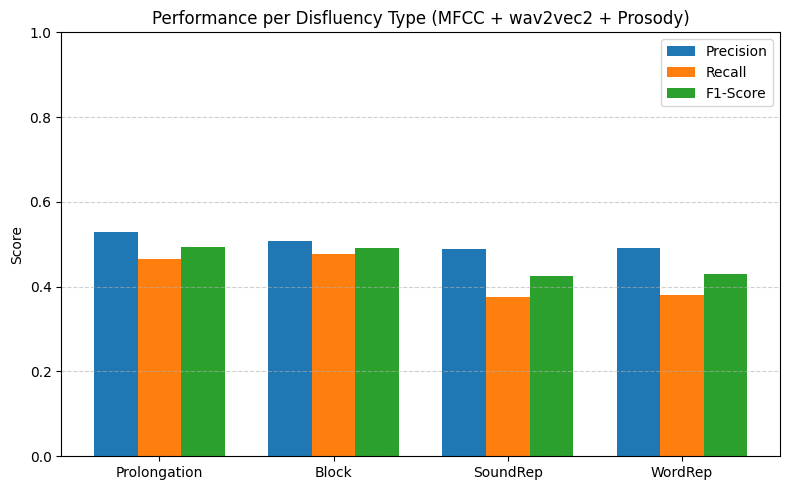

In [77]:
# Combine into a DataFrame
df = pd.DataFrame({
    "Label": label_cols,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1_score
})

# Plot grouped bar chart
plt.figure(figsize=(8,5))
x = np.arange(len(label_cols))
width = 0.25

plt.bar(x - width, df["Precision"], width, label="Precision")
plt.bar(x, df["Recall"], width, label="Recall")
plt.bar(x + width, df["F1-Score"], width, label="F1-Score")

plt.xticks(x, label_cols)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Performance per Disfluency Type (MFCC + wav2vec2 + Prosody)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


C:\Users\Nikhi\AppData\Local\Temp\ipykernel_2464\3808303326.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


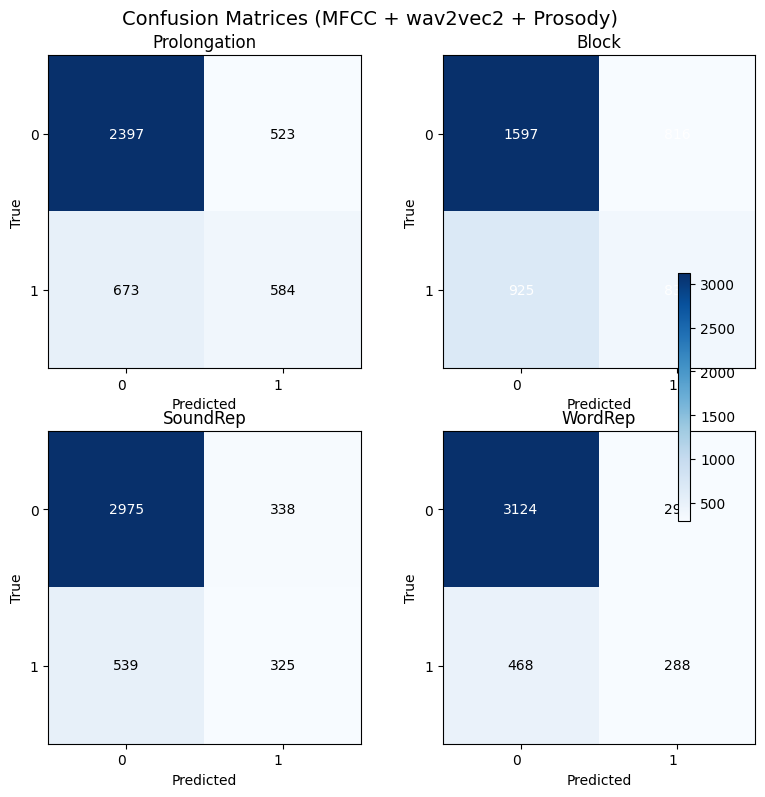

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# Define confusion matrices
cms = {
    "Prolongation": np.array([[2397, 523],
                              [673, 584]]),
    "Block": np.array([[1597, 816],
                       [925, 839]]),
    "SoundRep": np.array([[2975, 338],
                          [539, 325]]),
    "WordRep": np.array([[3124, 297],
                         [468, 288]])
}

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for ax, (lbl, cm) in zip(axes, cms.items()):
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(lbl)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # Add tick labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"], rotation=0, ha="right")
    ax.set_yticklabels(["0", "1"])

    # Annotate cells with counts
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black")

fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02)
fig.suptitle("Confusion Matrices (MFCC + wav2vec2 + Prosody)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
Prolongation Confusion Matrix:
[[TN= 2397  FP=  523]
 [FN=  673  TP=  584]]
Precision=0.528  Recall=0.465  F1=0.494

Block Confusion Matrix:
[[TN= 1597  FP=  816]
 [FN=  925  TP=  839]]
Precision=0.507  Recall=0.476  F1=0.491

SoundRep Confusion Matrix:
[[TN= 2975  FP=  338]
 [FN=  539  TP=  325]]
Precision=0.490  Recall=0.376  F1=0.426

WordRep Confusion Matrix:
[[TN= 3124  FP=  297]
 [FN=  468  TP=  288]]
Precision=0.492  Recall=0.381  F1=0.430

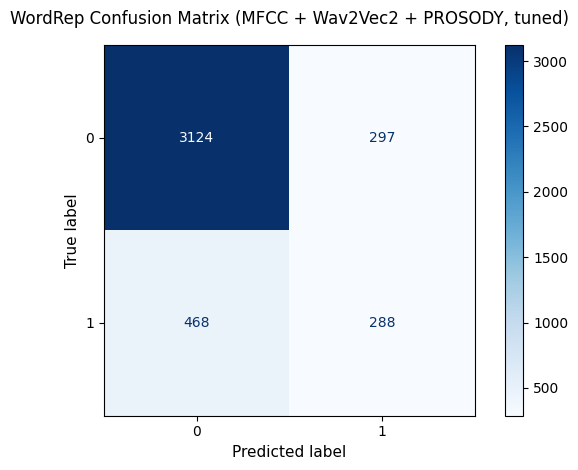

In [88]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# Example confusion matrix (replace with your own values)
cm = np.array([[3124, 297],
               [468,  288]])

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")

# Customize title, axis labels, and layout
plt.title("WordRep Confusion Matrix (MFCC + Wav2Vec2 + PROSODY, tuned)", fontsize=12, pad=15)
plt.xlabel("Predicted label", fontsize=11)
plt.ylabel("True label", fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.show()


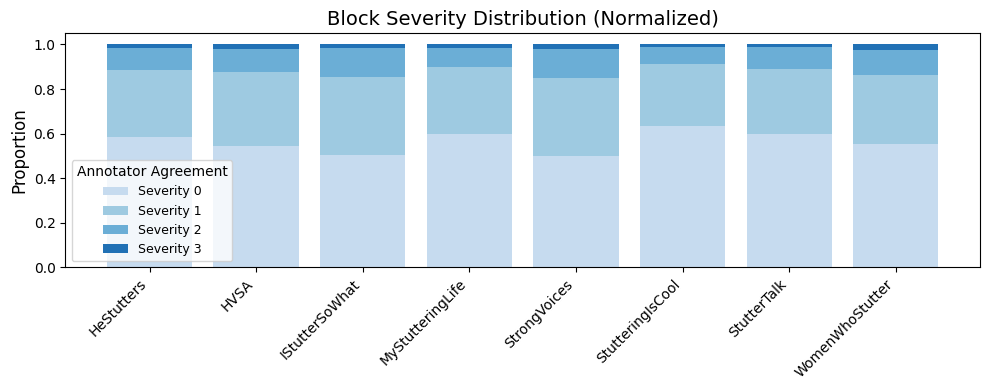

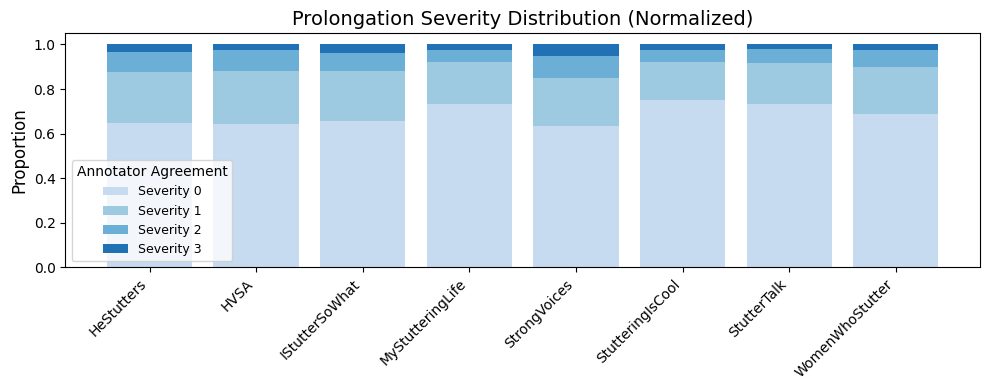

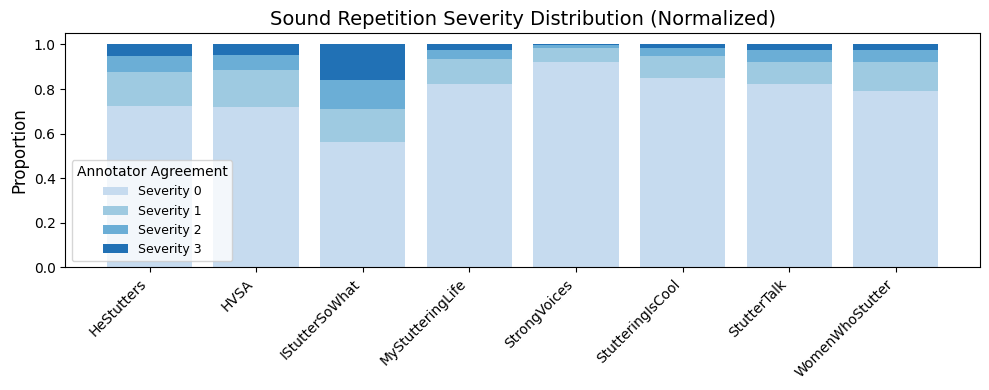

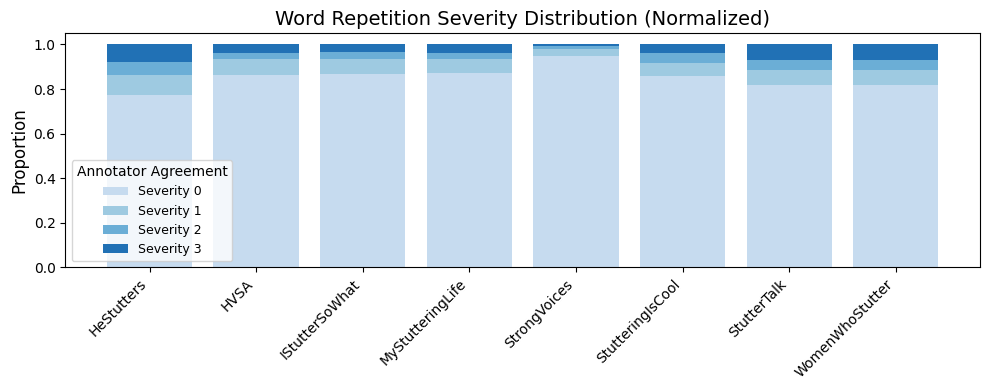

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# Dataset
# -----------------------------
speakers = [
    "HeStutters", "HVSA", "IStutterSoWhat", "MyStutteringLife",
    "StrongVoices", "StutteringIsCool", "StutterTalk", "WomenWhoStutter"
]

block = {
    0:[2156,402,439,1398,1156,2538,3037,5081],
    1:[1106,244,303,705,802,1122,1481,2837],
    2:[362,76,114,194,301,308,481,1006],
    3:[60,14,14,42,49,45,65,239]
}

prolong = {
    0:[2382,474,571,1715,1463,3006,3711,6309],
    1:[855,174,196,440,499,691,931,1948],
    2:[318,69,71,121,224,217,314,688],
    3:[129,19,32,63,122,99,108,218]
}

soundrep = {
    0:[2664,531,491,1929,2129,3402,4161,7256],
    1:[563,121,126,253,142,403,496,1168],
    2:[273,49,115,102,29,138,274,499],
    3:[184,35,138,55,8,70,133,240]
}

wordrep = {
    0:[2854,635,754,2042,2185,3437,4133,7516],
    1:[318,52,61,146,78,241,351,604],
    2:[217,21,27,65,29,176,234,391],
    3:[295,28,28,86,16,159,346,652]
}

datasets = {
    "Block": block,
    "Prolongation": prolong,
    "Sound Repetition": soundrep,
    "Word Repetition": wordrep
}

# -----------------------------
# Blue color palette (light → dark)
# -----------------------------
colors = ["#c6dbef", "#9ecae1", "#6baed6", "#2171b5"]

# -----------------------------
# Plotting Function
# -----------------------------
def plot_stacked_bar(name, data):
    df = pd.DataFrame(data, index=speakers)
    df_norm = df.div(df.sum(axis=1), axis=0)  # normalize rows to 1

    fig, ax = plt.subplots(figsize=(10, 4))

    bottom = np.zeros(len(df_norm))

    for i, col in enumerate(df_norm.columns):
        ax.bar(
            speakers, df_norm[col],
            bottom=bottom,
            color=colors[i],
            label=f"Severity {col}"
        )
        bottom += df_norm[col]

    ax.set_ylabel("Proportion", fontsize=12)
    ax.set_title(f"{name} Severity Distribution (Normalized)", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    ax.legend(title="Annotator Agreement", fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{name.lower().replace(' ','_')}_dist.png", dpi=300)
    plt.show()

# -----------------------------
# Generate all four plots
# -----------------------------
for name, data in datasets.items():
    plot_stacked_bar(name, data)


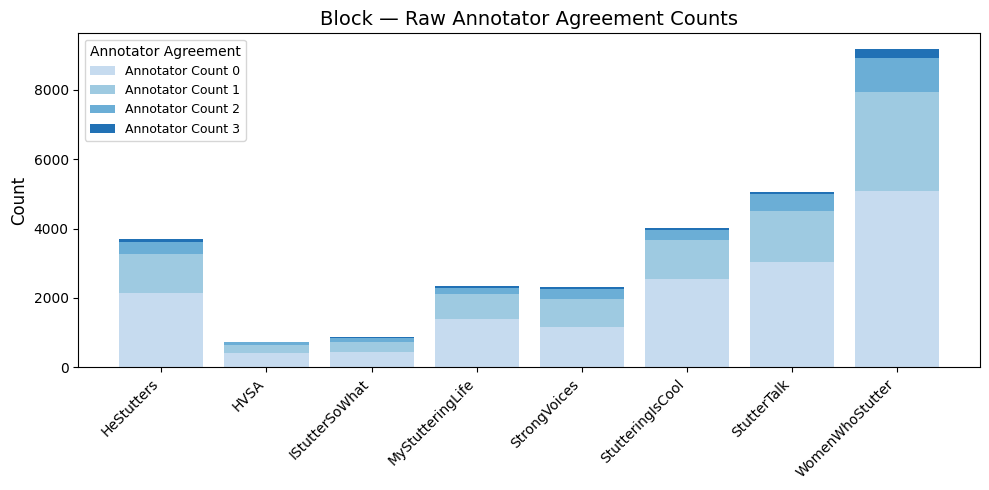

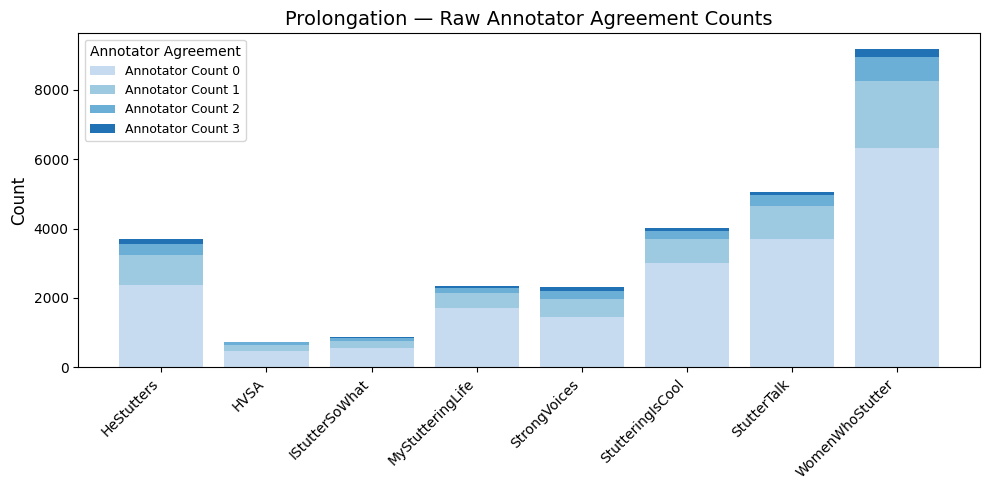

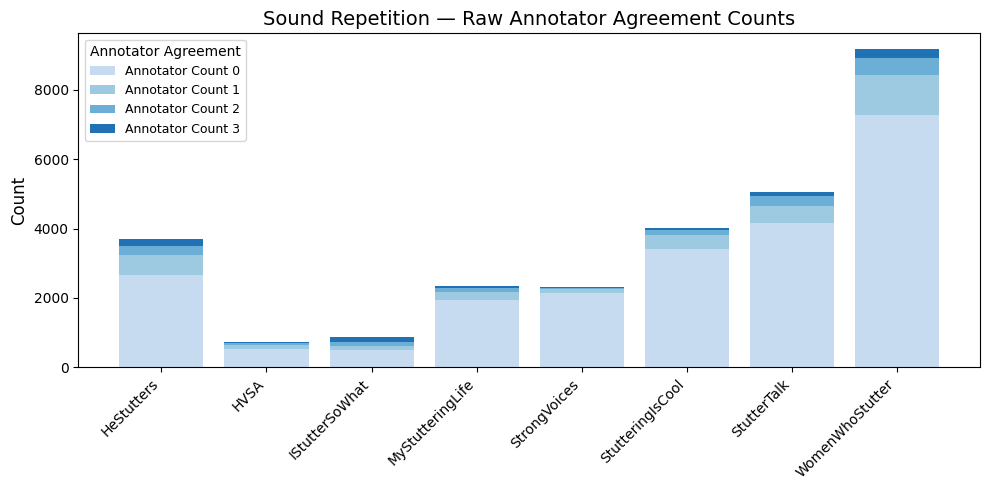

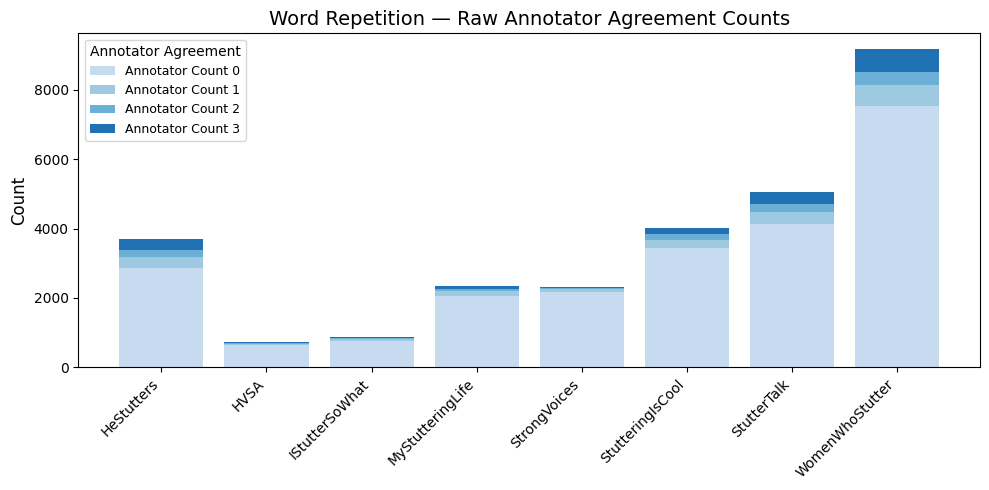

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# Dataset
# -----------------------------
speakers = [
    "HeStutters", "HVSA", "IStutterSoWhat", "MyStutteringLife",
    "StrongVoices", "StutteringIsCool", "StutterTalk", "WomenWhoStutter"
]

block = {
    0:[2156,402,439,1398,1156,2538,3037,5081],
    1:[1106,244,303,705,802,1122,1481,2837],
    2:[362,76,114,194,301,308,481,1006],
    3:[60,14,14,42,49,45,65,239]
}

prolong = {
    0:[2382,474,571,1715,1463,3006,3711,6309],
    1:[855,174,196,440,499,691,931,1948],
    2:[318,69,71,121,224,217,314,688],
    3:[129,19,32,63,122,99,108,218]
}

soundrep = {
    0:[2664,531,491,1929,2129,3402,4161,7256],
    1:[563,121,126,253,142,403,496,1168],
    2:[273,49,115,102,29,138,274,499],
    3:[184,35,138,55,8,70,133,240]
}

wordrep = {
    0:[2854,635,754,2042,2185,3437,4133,7516],
    1:[318,52,61,146,78,241,351,604],
    2:[217,21,27,65,29,176,234,391],
    3:[295,28,28,86,16,159,346,652]
}

datasets = {
    "Block": block,
    "Prolongation": prolong,
    "Sound Repetition": soundrep,
    "Word Repetition": wordrep
}

# -----------------------------
# Blue color palette (light → dark)
# -----------------------------
colors = ["#c6dbef", "#9ecae1", "#6baed6", "#2171b5"]

# -----------------------------
# Plotting function (RAW COUNTS)
# -----------------------------
def plot_stacked_raw(name, data):
    df = pd.DataFrame(data, index=speakers)

    fig, ax = plt.subplots(figsize=(10, 5))
    bottom = np.zeros(len(df))

    for i, col in enumerate(df.columns):
        ax.bar(speakers, df[col],
               bottom=bottom,
               color=colors[i],
               label=f"Annotator Count {col}")
        bottom += df[col]

    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(f"{name} — Raw Annotator Agreement Counts", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    ax.legend(title="Annotator Agreement", fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{name.lower().replace(' ','_')}_raw_counts.png", dpi=300)
    plt.show()

# -----------------------------
# Generate all 4 raw-count plots
# -----------------------------
for name, data in datasets.items():
    plot_stacked_raw(name, data)


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# Dataset
# -----------------------------
speakers = [
    "HeStutters", "HVSA", "IStutterSoWhat", "MyStutteringLife",
    "StrongVoices", "StutteringIsCool", "StutterTalk", "WomenWhoStutter"
]

block = {
    0:[2156,402,439,1398,1156,2538,3037,5081],
    1:[1106,244,303,705,802,1122,1481,2837],
    2:[362,76,114,194,301,308,481,1006],
    3:[60,14,14,42,49,45,65,239]
}

prolong = {
    0:[2382,474,571,1715,1463,3006,3711,6309],
    1:[855,174,196,440,499,691,931,1948],
    2:[318,69,71,121,224,217,314,688],
    3:[129,19,32,63,122,99,108,218]
}

soundrep = {
    0:[2664,531,491,1929,2129,3402,4161,7256],
    1:[563,121,126,253,142,403,496,1168],
    2:[273,49,115,102,29,138,274,499],
    3:[184,35,138,55,8,70,133,240]
}

wordrep = {
    0:[2854,635,754,2042,2185,3437,4133,7516],
    1:[318,52,61,146,78,241,351,604],
    2:[217,21,27,65,29,176,234,391],
    3:[295,28,28,86,16,159,346,652]
}

datasets = {
    "Block": block,
    "Prolongation": prolong,
    "SoundRepetition": soundrep,
    "WordRepetition": wordrep
}

# -----------------------------
# Blue palette (light → dark)
# -----------------------------
colors = ["#c6dbef", "#9ecae1", "#6baed6", "#2171b5"]

# -----------------------------
# Plot + Save Function
# -----------------------------
def save_raw_plot(name, data):
    df = pd.DataFrame(data, index=speakers)

    fig, ax = plt.subplots(figsize=(10, 5))
    bottom = np.zeros(len(df))

    # Stacked bars
    for i, col in enumerate(df.columns):
        ax.bar(
            speakers, df[col],
            bottom=bottom,
            color=colors[i],
            label=f"Severity {col}"
        )
        bottom += df[col]

    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(f"{name} — Raw Severity Counts", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    ax.legend(title="Severity", fontsize=9)

    plt.tight_layout()

    filename = f"{name.lower()}_raw_counts.png"
    plt.savefig(filename, dpi=300)
    plt.close()

    print(f"Saved: {filename}")

# -----------------------------
# Generate + Save All Plots
# -----------------------------
for name, data in datasets.items():
    save_raw_plot(name, data)


Saved: block_raw_counts.png
Saved: prolongation_raw_counts.png
Saved: soundrepetition_raw_counts.png
Saved: wordrepetition_raw_counts.png
